# CF pathogen phage-to-host ratios

Cross-sectional phage-to-host ratio (PTH) analysis for UHVDB virus species whose predicted hosts are CF pathogens, across all ~1.8k CF CoverM metagenomes.

**Inspired by** `figure_5/cf_activity_classifier.ipynb` (data loading / CoverM detections / Sylph tax).

**Host matching** (figure_5 exploratory hierarchical rules 1→2 only):
1. Predicted host **species** present in the sample → use that species taxonomic abundance
2. Else, predicted host **genus** has **exactly one** bacterial species in the sample → use that singleton
3. No most-abundant genus fallback

**CF pathogens:** *P. aeruginosa*, *S. aureus*, *H. influenzae*, *Achromobacter*, *Stenotrophomonas*, *Burkholderia*

**Environment:** `lgonsa` micromamba  
`micromamba activate lgonsa`  
Path: `/mmfs1/gscratch/pedslabs_hoffman/carsonjm/micromamba_envs/envs/lgonsa`

Outputs → `cf_pathogen_pth_results/`


In [34]:
### packages + paths
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from scipy import stats

plt.rcParams.update({"font.size": 12})

FIG_6 = Path.cwd().resolve()
if FIG_6.name != "figure_6":
    cand = FIG_6 / "uhvdb-manuscript" / "figure_6"
    if cand.is_dir():
        FIG_6 = cand
    elif (FIG_6 / "figure_6").is_dir():
        FIG_6 = FIG_6 / "figure_6"

FIG_5 = FIG_6.parent / "figure_5"
FIG_S18 = FIG_6.parent / "figure_s18"
OUT_DIR = FIG_6 / "cf_pathogen_pth_results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

COVERM_AGG = FIG_5 / "cf_metag_coverm_results.tsv.gz"
SYLPH_TAX = FIG_5 / "cf_metag_sylph_tax_results.tsv.gz"
METADATA = FIG_S18 / "uhvdb_v5_final_metadata_v2.tsv.gz"
PREDICTIONS = FIG_5 / "cf_activity_results" / "cf_caudoviricetes_predictions.tsv.gz"
READ_DEPTH = FIG_5 / "cf_metag_read_depth.txt.gz"
AIRWAY = FIG_5 / "cf_activity_results" / "cf_sample_type_airway3.tsv"

# CF pathogen genera (GTDB letter suffixes allowed, e.g. Pseudomonas_E).
# Haemophilus is restricted to H. influenzae only (see virus/bac filters).
CF_GENERA = [
    "Pseudomonas",
    "Staphylococcus",
    "Haemophilus",
    "Achromobacter",
    "Stenotrophomonas",
    "Burkholderia",
]
# Fixed tab10 colors by genus (sorted) so plots stay consistent even when
# a subset of CF pathogen genera is present.
CF_HOST_COLORS = dict(
    zip(
        sorted(CF_GENERA),
        sns.color_palette("tab10", n_colors=len(CF_GENERA)),
    )
)
CF_GENUS_RE = r"g__(" + "|".join(CF_GENERA) + r")(?:_[A-Z])?(?:[|;]|$)"
HAEMOPHILUS_INFLUENZAE_RE = r"s__Haemophilus(?:_[A-Z])? influenzae"

PRESENCE_THR = 1.0
DOMINANCE_THR = 50.0
PTH_THRESHOLDS = [1.0, 2.0, 3.0, 5.0]
HIGH_PTH_MEDIAN = 3.0
HIGH_PTH_MIN_SAMPLES = 3
DEPTH_MIN = 1e8

print("FIG_6:", FIG_6)
print("FIG_5:", FIG_5)
print("OUT_DIR:", OUT_DIR)


FIG_6: /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_6
FIG_5: /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_5
OUT_DIR: /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_6/cf_pathogen_pth_results


In [2]:
### Load inputs
coverm_df = pl.read_csv(COVERM_AGG, separator="\t")
print(
    f"CoverM: rows={coverm_df.height:,}  samples={coverm_df['sample_id'].n_unique():,}"
)

sylph_tax = pl.read_csv(SYLPH_TAX, separator="\t")
print(
    f"Sylph tax: rows={sylph_tax.height:,}  samples={sylph_tax['sample_id'].n_unique():,}"
)

uhvdb_full = pl.read_csv(METADATA, separator="\t")
# Drop RNA / RT ICTV classes (same as classifier)
_rna_rt = {"Riboviria", "Duplornavirales", "Lenarviricota", "Pisuviricota", "Negarnaviricota"}
# Keep all DNA viruses; metadata filter applied via species-rep map below
sp_meta = (
    uhvdb_full.filter(pl.col("seq_name") == pl.col("seqhash_rep"))
    .select(
        [
            "species_cluster_id",
            "genus_cluster_id",
            "family_cluster_id",
            "ictv_class",
            "ictv_family",
            "ictv_genus",
            "ictv_species",
            "final_host_pred",
        ]
    )
    .unique("species_cluster_id")
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
)
_id_ictv = (
    uhvdb_full.select(
        ["uhvdb_id", "seq_name", "seqhash_rep", "species_cluster_id", "ictv_class"]
    )
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
)
print(f"UHVDB species reps: {sp_meta.height:,}")

preds = None
if PREDICTIONS.exists():
    preds = (
        pl.read_csv(PREDICTIONS, separator="\t")
        .select(
            [
                "sample_id",
                "species_cluster_id",
                "predicted_inactive_probability",
                "predicted_uninducible",
            ]
        )
        .with_columns(
            [
                pl.col("species_cluster_id").cast(pl.Int64),
                pl.col("predicted_uninducible").cast(pl.Int64),
            ]
        )
    )
    print(f"Loaded predictions: {preds.height:,}")
else:
    print("WARNING: predictions file missing; uninducible join skipped")

read_depth = (
    pl.read_csv(READ_DEPTH, separator="\t", has_header=False)
    .rename({"column_1": "sample_id", "column_2": "read_depth"})
)
airway_labels = (
    pl.read_csv(AIRWAY, separator="\t")
    .select(["sample_id", "airway_category"])
    .unique("sample_id")
    if AIRWAY.exists()
    else pl.DataFrame({"sample_id": [], "airway_category": []})
)
print(f"Read depth samples: {read_depth.height:,}")
print(f"Airway labels: {airway_labels.height:,}")

coverm_samples = coverm_df["sample_id"].unique().to_list()
print(f"CoverM sample cohort: {len(coverm_samples):,}")


CoverM: rows=72,431  samples=1,809
Sylph tax: rows=603,548  samples=1,888
UHVDB species reps: 206,219
Loaded predictions: 60,855
Read depth samples: 1,959
Airway labels: 1,809
CoverM sample cohort: 1,809


In [3]:
### CoverM species-rep detections
coverm_det = (
    coverm_df.filter(pl.col("breadth_ratio") > 0)
    .join(_id_ictv, left_on="contig_id", right_on="uhvdb_id", how="left")
    .filter(pl.col("seq_name") == pl.col("seqhash_rep"))
    .sort(
        ["sample_id", "species_cluster_id", "breadth_ratio"],
        descending=[False, False, True],
    )
    .unique(["sample_id", "species_cluster_id"], keep="first")
    .select(
        [
            "sample_id",
            "species_cluster_id",
            "contig_id",
            "ictv_class",
            "breadth_ratio",
        ]
    )
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
)
print(
    f"CoverM species-rep detections: {coverm_det.height:,}  "
    f"samples={coverm_det['sample_id'].n_unique():,}"
)


CoverM species-rep detections: 72,361  samples=1,809


In [12]:
### Sylph virus + bacterial tables; CF-pathogen virus detections
# Virus rows with predicted host
virus_sylph = (
    sylph_tax.filter(pl.col("sample_id").is_in(coverm_samples))
    .filter(pl.col("virus_host").is_not_null())
    .filter(pl.col("clade_name").str.contains(r"vSPECIES-"))
    .with_columns(
        [
            pl.col("virus_host").str.replace_all(";", "|").alias("virus_host"),
            pl.col("clade_name")
            .str.extract(r"vSPECIES-(\d+)", 1)
            .cast(pl.Int64)
            .alias("species_cluster_id"),
            pl.col("taxonomic_abundance").alias("virus_abund"),
        ]
    )
    .with_columns(
        [
            pl.col("virus_host").str.extract(r"g__([^|;]+)", 1).alias("host_genus_raw"),
            pl.col("virus_host").str.contains("s__").fill_null(False).alias("has_species_host"),
            pl.col("virus_host").str.contains("g__").fill_null(False).alias("has_genus_host"),
        ]
    )
    .with_columns(
        # Collapse GTDB letter suffixes (Haemophilus_A → Haemophilus)
        pl.col("host_genus_raw")
        .str.replace(r"_([A-Z])$", "")
        .alias("host_genus")
    )
)

# Restrict to CF pathogen genera; Haemophilus → H. influenzae only
virus_cf = virus_sylph.filter(
    (
        pl.col("host_genus").is_in(
            [g for g in CF_GENERA if g != "Haemophilus"]
        )
    )
    | (
        (pl.col("host_genus") == "Haemophilus")
        & pl.col("virus_host").str.contains(HAEMOPHILUS_INFLUENZAE_RE)
    )
)

# Intersect with CoverM detections
virus_det = (
    coverm_det.select(["sample_id", "species_cluster_id", "breadth_ratio"])
    .join(
        virus_cf.select(
            [
                "sample_id",
                "species_cluster_id",
                "virus_host",
                "virus_abund",
                "host_genus_raw",
                "host_genus",
                "has_species_host",
                "has_genus_host",
            ]
        ),
        on=["sample_id", "species_cluster_id"],
        how="inner",
    )
    .join(
        sp_meta.select(
            [
                "species_cluster_id",
                "genus_cluster_id",
                "family_cluster_id",
                "ictv_class",
                "ictv_family",
                "ictv_genus",
                "ictv_species",
            ]
        ),
        on="species_cluster_id",
        how="left",
    )
)

print(
    f"CF-pathogen virus detections (CoverM ∩ Sylph): {virus_det.height:,}  "
    f"samples={virus_det['sample_id'].n_unique():,}  "
    f"species={virus_det['species_cluster_id'].n_unique():,}"
)
print(virus_det.group_by("host_genus").len().sort("len", descending=True))

# Bacterial species-level abundances in CF pathogen genera
bac_in_sample = (
    sylph_tax.filter(pl.col("sample_id").is_in(coverm_samples))
    .filter(pl.col("clade_name").str.starts_with("d__Bacteria"))
    .filter(pl.col("clade_name").str.contains(r"s__"))
    .filter(~pl.col("clade_name").str.contains(r"t__"))
    .with_columns(
        [
            pl.col("clade_name").alias("bac_species"),
            pl.col("taxonomic_abundance").alias("bac_taxonomic_abundance"),
            pl.col("relative_abundance").alias("bac_rel"),
            pl.col("clade_name").str.extract(r"g__([^|;]+)", 1).alias("bac_genus_raw"),
        ]
    )
    .with_columns(
        pl.col("bac_genus_raw").str.replace(r"_([A-Z])$", "").alias("bac_genus")
    )
    .filter(pl.col("bac_genus").is_in(CF_GENERA))
    # Haemophilus: keep H. influenzae only as bacterial denominator / host match
    .filter(
        (pl.col("bac_genus") != "Haemophilus")
        | pl.col("bac_species").str.contains(HAEMOPHILUS_INFLUENZAE_RE)
    )
    .select(
        [
            "sample_id",
            "bac_species",
            "bac_genus",
            "bac_genus_raw",
            "bac_taxonomic_abundance",
            "bac_rel",
        ]
    )
)
print(
    f"CF-pathogen bacterial species rows: {bac_in_sample.height:,}  "
    f"samples={bac_in_sample['sample_id'].n_unique():,}"
)
print(bac_in_sample.group_by("bac_genus").agg(pl.col("sample_id").n_unique().alias("n_samples")).sort("n_samples", descending=True))


CF-pathogen virus detections (CoverM ∩ Sylph): 5,657  samples=1,210  species=732
shape: (6, 2)
┌──────────────────┬──────┐
│ host_genus       ┆ len  │
│ ---              ┆ ---  │
│ str              ┆ u32  │
╞══════════════════╪══════╡
│ Staphylococcus   ┆ 2657 │
│ Pseudomonas      ┆ 2245 │
│ Stenotrophomonas ┆ 349  │
│ Haemophilus      ┆ 186  │
│ Burkholderia     ┆ 129  │
│ Achromobacter    ┆ 91   │
└──────────────────┴──────┘
CF-pathogen bacterial species rows: 1,679  samples=1,157
shape: (6, 2)
┌──────────────────┬───────────┐
│ bac_genus        ┆ n_samples │
│ ---              ┆ ---       │
│ str              ┆ u32       │
╞══════════════════╪═══════════╡
│ Staphylococcus   ┆ 561       │
│ Pseudomonas      ┆ 559       │
│ Haemophilus      ┆ 217       │
│ Stenotrophomonas ┆ 124       │
│ Burkholderia     ┆ 79        │
│ Achromobacter    ┆ 73        │
└──────────────────┴───────────┘


In [13]:
### Hierarchical PTH: species present → genus singleton fallback
# Rule 1: predicted species host present in sample
rule1 = (
    virus_det.filter(pl.col("has_species_host"))
    .join(
        bac_in_sample.select(
            [
                "sample_id",
                pl.col("bac_species").alias("virus_host"),
                pl.col("bac_taxonomic_abundance").alias("host_abundance"),
                pl.col("bac_species").alias("vhr_host"),
            ]
        ),
        on=["sample_id", "virus_host"],
        how="inner",
    )
    .with_columns(pl.lit("species").alias("match_method"))
)

# Per sample × genus: singleton members
genus_members = (
    bac_in_sample.filter(pl.col("bac_genus").is_not_null())
    .group_by(["sample_id", "bac_genus"])
    .agg(
        [
            pl.len().alias("n_species_in_genus"),
            pl.col("bac_species")
            .sort_by("bac_taxonomic_abundance", descending=True)
            .first()
            .alias("top_species"),
            pl.col("bac_taxonomic_abundance").max().alias("top_abundance"),
        ]
    )
    .rename({"bac_genus": "host_genus"})
)

# Rule 2: exactly one genus member present
rule2 = (
    virus_det.filter(pl.col("has_genus_host") & pl.col("host_genus").is_not_null())
    .join(
        genus_members.filter(pl.col("n_species_in_genus") == 1),
        on=["sample_id", "host_genus"],
        how="inner",
    )
    .with_columns(
        [
            pl.col("top_species").alias("vhr_host"),
            pl.col("top_abundance").alias("host_abundance"),
            pl.lit("genus_singleton").alias("match_method"),
        ]
    )
)

keys = ["sample_id", "species_cluster_id"]
pth_df = (
    virus_det.join(
        rule1.select(
            keys
            + [
                "vhr_host",
                "host_abundance",
                "match_method",
            ]
        ),
        on=keys,
        how="left",
    )
    .join(
        rule2.select(
            keys
            + [
                pl.col("vhr_host").alias("vhr_host_r2"),
                pl.col("host_abundance").alias("host_abundance_r2"),
                pl.col("match_method").alias("match_method_r2"),
            ]
        ),
        on=keys,
        how="left",
    )
    .with_columns(
        [
            pl.when(pl.col("vhr_host").is_not_null())
            .then(pl.col("vhr_host"))
            .otherwise(pl.col("vhr_host_r2"))
            .alias("vhr_host"),
            pl.when(pl.col("host_abundance").is_not_null())
            .then(pl.col("host_abundance"))
            .otherwise(pl.col("host_abundance_r2"))
            .alias("host_abundance"),
            pl.when(pl.col("match_method").is_not_null())
            .then(pl.col("match_method"))
            .otherwise(pl.col("match_method_r2"))
            .alias("match_method"),
        ]
    )
    .filter(pl.col("host_abundance").is_not_null() & (pl.col("host_abundance") > 0))
    .with_columns((pl.col("virus_abund") / pl.col("host_abundance")).alias("pth"))
    .drop([c for c in ["vhr_host_r2", "host_abundance_r2", "match_method_r2"] if c in ["vhr_host_r2", "host_abundance_r2", "match_method_r2"]])
)

# Join uninducible predictions when available
if preds is not None:
    pth_df = pth_df.join(
        preds.select(
            [
                "sample_id",
                "species_cluster_id",
                "predicted_inactive_probability",
                "predicted_uninducible",
            ]
        ),
        on=["sample_id", "species_cluster_id"],
        how="left",
    )

# Airway + depth
pth_df = (
    pth_df.join(airway_labels, on="sample_id", how="left")
    .join(read_depth, on="sample_id", how="left")
    .with_columns(
        pl.col("host_genus").alias("pathogen")
    )
)

n_det = virus_det.height
n_assigned = pth_df.height
print("=== Hierarchical host assignment (species → genus singleton) ===")
print(f"CF-pathogen detections: {n_det:,}")
print(f"Detections with usable PTH: {n_assigned:,} ({n_assigned / n_det:.1%})")
print("\nBy match_method:")
print(
    pth_df.group_by("match_method")
    .len()
    .with_columns((pl.col("len") / n_assigned).alias("frac"))
    .sort("match_method")
)
print("\nBy pathogen:")
print(
    pth_df.group_by("pathogen")
    .agg(
        [
            pl.len().alias("n_detections"),
            pl.col("sample_id").n_unique().alias("n_samples"),
            pl.col("species_cluster_id").n_unique().alias("n_species"),
            pl.col("pth").median().alias("median_pth"),
        ]
    )
    .sort("n_detections", descending=True)
)


=== Hierarchical host assignment (species → genus singleton) ===
CF-pathogen detections: 5,657
Detections with usable PTH: 5,222 (92.3%)

By match_method:
shape: (2, 3)
┌─────────────────┬──────┬──────────┐
│ match_method    ┆ len  ┆ frac     │
│ ---             ┆ ---  ┆ ---      │
│ str             ┆ u32  ┆ f64      │
╞═════════════════╪══════╪══════════╡
│ genus_singleton ┆ 392  ┆ 0.075067 │
│ species         ┆ 4830 ┆ 0.924933 │
└─────────────────┴──────┴──────────┘

By pathogen:
shape: (6, 5)
┌──────────────────┬──────────────┬───────────┬───────────┬────────────┐
│ pathogen         ┆ n_detections ┆ n_samples ┆ n_species ┆ median_pth │
│ ---              ┆ ---          ┆ ---       ┆ ---       ┆ ---        │
│ str              ┆ u32          ┆ u32       ┆ u32       ┆ f64        │
╞══════════════════╪══════════════╪═══════════╪═══════════╪════════════╡
│ Staphylococcus   ┆ 2271         ┆ 469       ┆ 244       ┆ 0.966626   │
│ Pseudomonas      ┆ 2217         ┆ 472       ┆ 324       ┆ 1

In [14]:
### Write per-detection PTH table
det_out = pth_df.select(
    [
        "sample_id",
        "species_cluster_id",
        "genus_cluster_id",
        "family_cluster_id",
        "pathogen",
        "host_genus",
        "virus_host",
        "vhr_host",
        "match_method",
        "virus_abund",
        "host_abundance",
        "pth",
        "ictv_class",
        "ictv_family",
        "ictv_genus",
        "ictv_species",
        "breadth_ratio",
        "airway_category",
        "read_depth",
        *[
            c
            for c in [
                "predicted_inactive_probability",
                "predicted_uninducible",
            ]
            if c in pth_df.columns
        ],
    ]
)

det_path = OUT_DIR / "cf_pathogen_pth_detections.tsv.gz"
det_out.write_csv(det_path, separator="\t", compression="gzip")
print("Saved", det_path, f"({det_out.height:,} rows)")
det_out.head()


Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_6/cf_pathogen_pth_results/cf_pathogen_pth_detections.tsv.gz (5,222 rows)


sample_id,species_cluster_id,genus_cluster_id,family_cluster_id,pathogen,host_genus,virus_host,vhr_host,match_method,virus_abund,host_abundance,pth,ictv_class,ictv_family,ictv_genus,ictv_species,breadth_ratio,airway_category,read_depth,predicted_inactive_probability,predicted_uninducible
str,i64,i64,i64,str,str,str,str,str,f64,f64,f64,str,str,str,str,f64,str,i64,f64,i64
"""SAMN33100409_SRR23346274_cf""",62186,496,18,"""Staphylococcus""","""Staphylococcus""","""d__Bacteria|p__Bacillota|c__Ba…","""d__Bacteria|p__Bacillota|c__Ba…","""species""",0.0292,0.03,0.973333,"""Caudoviricetes""",null,"""Biseptimavirus""","""Biseptimavirus NM3""",0.758707,"""upper_airway""",1105758864,0.87,0
"""SAMN27562210_SRR19051579_cf""",2,496,18,"""Staphylococcus""","""Staphylococcus""","""d__Bacteria|p__Bacillota|c__Ba…","""d__Bacteria|p__Bacillota|c__Ba…","""species""",7.3037,7.1701,1.018633,"""Caudoviricetes""",null,"""Biseptimavirus""","""Biseptimavirus NM3""",0.824009,"""lower_airway""",91190857,0.59,0
"""SAMN10805726_SRR8482159_cf""",4692,1633,99,"""Pseudomonas""","""Pseudomonas""","""d__Bacteria|p__Pseudomonadota|…","""d__Bacteria|p__Pseudomonadota|…","""species""",9.5788,5.2184,1.835582,"""Caudoviricetes""",null,"""Stanholtvirus""","""Stanholtvirus sv1026b""",0.877103,"""lower_airway""",121796292,0.47,0
"""SAMN40589491_SRR28442049_cf""",20488,778,222,"""Pseudomonas""","""Pseudomonas""","""d__Bacteria|p__Pseudomonadota|…","""d__Bacteria|p__Pseudomonadota|…","""species""",0.0254,8.0773,0.003145,"""Faserviricetes""","""Inoviridae""","""Primolicivirus""","""Primolicivirus Pf8""",0.868207,"""lower_airway""",14629012563,null,null
"""SAMN11310321_SRR8834146_cf""",4221,4313,21,"""Pseudomonas""","""Pseudomonas""","""d__Bacteria|p__Pseudomonadota|…","""d__Bacteria|p__Pseudomonadota|…","""species""",2.7454,2.4152,1.136717,"""Caudoviricetes""","""Peduoviridae""","""Mersinvirus""","""Mersinvirus YA0848V""",0.674259,"""lower_airway""",126507011,0.86,0


In [15]:
### Per-taxon PTH summaries (species / genus / family)
def taxon_summary(df: pl.DataFrame, level: str, id_col: str) -> pl.DataFrame:
    return (
        df.group_by(id_col)
        .agg(
            [
                pl.len().alias("n_samples_with_pth"),
                pl.col("pth").mean().alias("mean_pth"),
                pl.col("pth").median().alias("median_pth"),
                pl.col("pth").quantile(0.75).alias("q75_pth"),
                (pl.col("pth") >= 2).mean().alias("frac_pth_ge_2"),
                (pl.col("pth") >= 3).mean().alias("frac_pth_ge_3"),
                (pl.col("pth") >= 5).mean().alias("frac_pth_ge_5"),
                (pl.col("pth") >= 3).sum().alias("n_pth_ge_3"),
                pl.col("host_abundance").median().alias("median_host_abund"),
                pl.col("virus_abund").median().alias("median_virus_abund"),
                pl.col("species_cluster_id").n_unique().alias("n_member_species"),
                pl.col("pathogen").mode().first().alias("pathogen"),
                pl.col("ictv_class").mode().first().alias("ictv_class"),
                pl.col("ictv_family").mode().first().alias("ictv_family"),
                pl.col("ictv_genus").mode().first().alias("ictv_genus"),
                pl.col("ictv_species").mode().first().alias("ictv_species"),
                pl.col("vhr_host").mode().first().alias("consensus_host"),
            ]
        )
        .with_columns(
            [
                pl.lit(level).alias("taxonomic_level"),
                pl.col(id_col).cast(pl.Int64).alias("taxon_id"),
                (
                    (pl.col("median_pth") >= HIGH_PTH_MEDIAN)
                    & (pl.col("n_samples_with_pth") >= HIGH_PTH_MIN_SAMPLES)
                ).alias("consistently_high_pth"),
            ]
        )
        .sort(["pathogen", "median_pth"], descending=[False, True])
    )


pth_unique = pth_df.unique(["sample_id", "species_cluster_id"])

sum_species = taxon_summary(pth_unique, "Species", "species_cluster_id")
sum_genus = taxon_summary(
    pth_unique.filter(pl.col("genus_cluster_id").is_not_null()),
    "Genus",
    "genus_cluster_id",
)
sum_family = taxon_summary(
    pth_unique.filter(pl.col("family_cluster_id").is_not_null()),
    "Family",
    "family_cluster_id",
)

out_cols = [
    "taxon_id",
    "taxonomic_level",
    "pathogen",
    "n_samples_with_pth",
    "mean_pth",
    "median_pth",
    "q75_pth",
    "frac_pth_ge_2",
    "frac_pth_ge_3",
    "frac_pth_ge_5",
    "n_pth_ge_3",
    "median_host_abund",
    "median_virus_abund",
    "n_member_species",
    "ictv_class",
    "ictv_family",
    "ictv_genus",
    "ictv_species",
    "consensus_host",
    "consistently_high_pth",
]

pth_by_taxon = pl.concat(
    [
        sum_species.select(out_cols),
        sum_genus.select(out_cols),
        sum_family.select(out_cols),
    ]
)

taxon_path = OUT_DIR / "cf_pathogen_pth_by_taxon.tsv.gz"
pth_by_taxon.write_csv(taxon_path, separator="\t", compression="gzip")
print("Saved", taxon_path, f"({pth_by_taxon.height:,} rows)")

high_pth = pth_by_taxon.filter(pl.col("consistently_high_pth"))
high_path = OUT_DIR / "cf_pathogen_consistently_high_pth.tsv.gz"
high_pth.write_csv(high_path, separator="\t", compression="gzip")
print(
    f"Consistently high PTH (median≥{HIGH_PTH_MEDIAN}, n≥{HIGH_PTH_MIN_SAMPLES}): "
    f"{high_pth.height:,}"
)
print(
    high_pth.select(
        [
            "taxonomic_level",
            "taxon_id",
            "pathogen",
            "median_pth",
            "n_samples_with_pth",
            "ictv_class",
        ]
    ).head(20)
)


Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_6/cf_pathogen_pth_results/cf_pathogen_pth_by_taxon.tsv.gz (1,039 rows)
Consistently high PTH (median≥3.0, n≥3): 25
shape: (20, 6)
┌─────────────────┬──────────┬──────────────────┬────────────┬────────────────────┬────────────────┐
│ taxonomic_level ┆ taxon_id ┆ pathogen         ┆ median_pth ┆ n_samples_with_pth ┆ ictv_class     │
│ ---             ┆ ---      ┆ ---              ┆ ---        ┆ ---                ┆ ---            │
│ str             ┆ i64      ┆ str              ┆ f64        ┆ u32                ┆ str            │
╞═════════════════╪══════════╪══════════════════╪════════════╪════════════════════╪════════════════╡
│ Species         ┆ 25597    ┆ Burkholderia     ┆ 3.119119   ┆ 4                  ┆ Caudoviricetes │
│ Species         ┆ 3865     ┆ Pseudomonas      ┆ 10.346651  ┆ 4                  ┆ Faserviricetes │
│ Species         ┆ 61229    ┆ Pseudomonas      ┆ 6.788431   ┆ 5    

Removed uninducible: 1,270  remaining=3,952


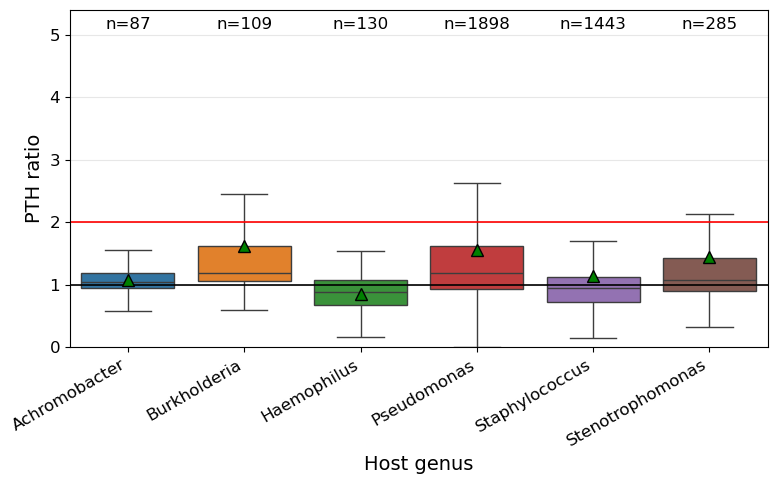

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_6/cf_pathogen_pth_results/cf_pathogen_pth_by_genus.png
Overall median PTH (uninducible removed): 1.058551340734906
Detections with PTH ≥ 2: 415 / 3,952 (10.5%)
Unique virus species with ≥1 detection PTH ≥ 2: 189
Faserviricetes among these species: 76 / 189 (40.2%)

Predicted hosts of these virus species:
shape: (5, 3)
┌──────────────────┬─────────────────┬──────────────┐
│ pathogen         ┆ n_virus_species ┆ n_detections │
│ ---              ┆ ---             ┆ ---          │
│ str              ┆ u32             ┆ u32          │
╞══════════════════╪═════════════════╪══════════════╡
│ Pseudomonas      ┆ 113             ┆ 294          │
│ Staphylococcus   ┆ 42              ┆ 63           │
│ Stenotrophomonas ┆ 22              ┆ 39           │
│ Burkholderia     ┆ 9               ┆ 16           │
│ Achromobacter    ┆ 3               ┆ 3            │
└──────────────────┴─────────────────┴───────

In [39]:
### Plot: PTH by pathogen genus
# Exclude predicted-uninducible Caudoviricetes (keep null / not-uninducible).
plot_df = pth_df
if "predicted_uninducible" in pth_df.columns:
    n_before = plot_df.height
    plot_df = plot_df.filter(
        (pl.col("predicted_uninducible").is_null())
        | (pl.col("predicted_uninducible") != 1)
    )
    print(
        f"Removed uninducible: {n_before - plot_df.height:,}  "
        f"remaining={plot_df.height:,}"
    )

genus_order = sorted(plot_df["pathogen"].drop_nulls().unique().to_list())
genus_count = (
    plot_df.group_by("pathogen").len().to_pandas().set_index("pathogen")["len"].to_dict()
)
genus_palette = {g: CF_HOST_COLORS[g] for g in genus_order if g in CF_HOST_COLORS}

pdf = plot_df.select(["pathogen", "pth", "match_method"]).to_pandas()
pdf = pdf[np.isfinite(pdf["pth"]) & (pdf["pth"] > 0)]

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=pdf,
    x="pathogen",
    y="pth",
    order=genus_order,
    hue="pathogen",
    hue_order=genus_order,
    palette=genus_palette,
    dodge=False,
    legend=False,
    showfliers=False,
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "black",
        "markersize": 8,
    },
    ax=ax,
)
ax.set_xticks(range(len(genus_order)))
ax.set_xticklabels(genus_order, rotation=30, ha="right")
ax.set_xlabel("Host genus", fontsize=14)
ax.set_ylabel("PTH ratio", fontsize=14)
# ax.set_yscale("log")
ax.set_ylim(0, 5.4)
# ax.set_title(
#     "CF pathogen phage-to-host ratios "
#     "(species → genus singleton; uninducible removed)"
# )
ax.axhline(1, color="black", linewidth=1.2)
ax.axhline(2, color="red", linewidth=1.2)
for i, genus in enumerate(genus_order):
    ax.text(
        i,
        5.05,
        f"n={genus_count.get(genus, 0)}",
        ha="center",
        va="bottom",
        fontsize=12,
    )
ax.tick_params(axis="x", rotation=30)
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
png = OUT_DIR / "cf_pathogen_pth_by_genus.png"
fig.savefig(png, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", png)
print("Overall median PTH (uninducible removed):", float(plot_df["pth"].median()))
n_pth_ge2 = plot_df.filter(pl.col("pth") >= 2.0).height
print(
    f"Detections with PTH ≥ 2: {n_pth_ge2:,} / {plot_df.height:,} "
    f"({n_pth_ge2 / plot_df.height:.1%})"
)

high_pth = plot_df.filter(pl.col("pth") >= 2.0)
high_pth_species = (
    high_pth.group_by("species_cluster_id")
    .agg(
        [
            pl.len().alias("n_detections"),
            pl.col("sample_id").n_unique().alias("n_samples"),
            pl.col("pth").median().alias("median_pth"),
            pl.col("pth").max().alias("max_pth"),
            pl.col("pathogen").mode().first().alias("pathogen"),
            pl.col("virus_host").mode().first().alias("virus_host"),
            pl.col("ictv_species").mode().first().alias("ictv_species"),
            pl.col("ictv_genus").mode().first().alias("ictv_genus"),
        ]
    )
    .sort(["n_detections", "median_pth"], descending=[True, True])
)
print(
    f"Unique virus species with ≥1 detection PTH ≥ 2: "
    f"{high_pth_species.height:,}"
)
n_faser = high_pth.filter(pl.col("ictv_class") == "Faserviricetes")[
    "species_cluster_id"
].n_unique()
print(
    f"Faserviricetes among these species: {n_faser:,} / {high_pth_species.height:,} "
    f"({n_faser / high_pth_species.height:.1%})"
)
print("\nPredicted hosts of these virus species:")
print(
    high_pth_species.group_by("pathogen")
    .agg(
        [
            pl.len().alias("n_virus_species"),
            pl.col("n_detections").sum().alias("n_detections"),
        ]
    )
    .sort("n_virus_species", descending=True)
)
print("\nVirus species with PTH ≥ 2 (predicted host = virus_host):")
print(
    high_pth_species.select(
        [
            "species_cluster_id",
            "pathogen",
            "virus_host",
            "ictv_genus",
            "ictv_species",
            "n_detections",
            "n_samples",
            "median_pth",
            "max_pth",
        ]
    )
)

=== All-virus hierarchical PTH (species → genus singleton) ===
1) Detections not classified as uninducible: 54,970
2) Not uninducible + predicted host: 51,802
3) Not uninducible + calculated PTH: 19,103
   (94.2% of #1 have a predicted host; 34.8% of #1 have PTH; 36.9% of #2 have PTH)
Overall median PTH: 1.0296

By match_method:
shape: (2, 3)
┌─────────────────┬───────┬──────────┐
│ match_method    ┆ len   ┆ frac     │
│ ---             ┆ ---   ┆ ---      │
│ str             ┆ u32   ┆ f64      │
╞═════════════════╪═══════╪══════════╡
│ genus_singleton ┆ 5738  ┆ 0.300372 │
│ species         ┆ 13365 ┆ 0.699628 │
└─────────────────┴───────┴──────────┘

Host genera with ≥10 virus species: 66
shape: (25, 6)
┌─────────────────────┬──────────────┬───────────┬─────────────────┬────────────┬───────────┐
│ host_genus          ┆ n_detections ┆ n_samples ┆ n_virus_species ┆ median_pth ┆ mean_pth  │
│ ---                 ┆ ---          ┆ ---       ┆ ---             ┆ ---        ┆ ---       │
│ str 

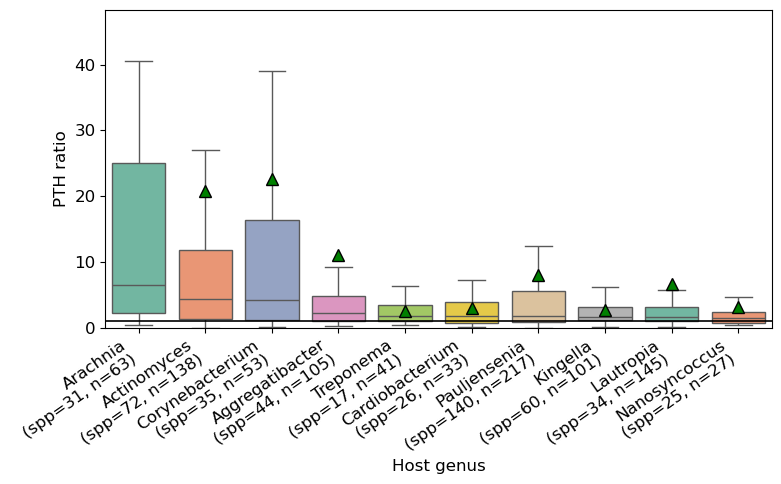

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_6/cf_pathogen_pth_results/all_virus_pth_top10_host_genera.png
Wrote /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_6/cf_pathogen_pth_results/all_virus_pth_by_host_genus.tsv.gz
Overall median PTH (all viruses, uninducible removed): 1.0295566502463054


In [36]:
### All-virus PTH: top host genera by median PTH
# Expand beyond CF pathogens: hierarchical PTH (species → genus singleton)
# for all CoverM ∩ Sylph virus detections with a predicted host, then plot
# the 10 host genera with highest median PTH (≥10 unique virus species).

MIN_VIRUS_SPECIES = 10
TOP_N_HOST_GENERA = 10

# All virus detections (CoverM ∩ Sylph), not CF-restricted
virus_det_all = (
    coverm_det.select(["sample_id", "species_cluster_id", "breadth_ratio"])
    .join(
        virus_sylph.select(
            [
                "sample_id",
                "species_cluster_id",
                "virus_host",
                "virus_abund",
                "host_genus_raw",
                "host_genus",
                "has_species_host",
                "has_genus_host",
            ]
        ),
        on=["sample_id", "species_cluster_id"],
        how="inner",
    )
    .join(
        sp_meta.select(
            [
                "species_cluster_id",
                "genus_cluster_id",
                "family_cluster_id",
                "ictv_class",
                "ictv_family",
                "ictv_genus",
                "ictv_species",
            ]
        ),
        on="species_cluster_id",
        how="left",
    )
)

# All bacterial species (not CF-restricted)
bac_in_sample_all = (
    sylph_tax.filter(pl.col("sample_id").is_in(coverm_samples))
    .filter(pl.col("clade_name").str.starts_with("d__Bacteria"))
    .filter(pl.col("clade_name").str.contains(r"s__"))
    .filter(~pl.col("clade_name").str.contains(r"t__"))
    .with_columns(
        [
            pl.col("clade_name").alias("bac_species"),
            pl.col("taxonomic_abundance").alias("bac_taxonomic_abundance"),
            pl.col("relative_abundance").alias("bac_rel"),
            pl.col("clade_name").str.extract(r"g__([^|;]+)", 1).alias("bac_genus_raw"),
        ]
    )
    .with_columns(
        pl.col("bac_genus_raw").str.replace(r"_([A-Z])$", "").alias("bac_genus")
    )
    .filter(pl.col("bac_genus").is_not_null())
    .select(
        [
            "sample_id",
            "bac_species",
            "bac_genus",
            "bac_genus_raw",
            "bac_taxonomic_abundance",
            "bac_rel",
        ]
    )
)

rule1_all = (
    virus_det_all.filter(pl.col("has_species_host"))
    .join(
        bac_in_sample_all.select(
            [
                "sample_id",
                pl.col("bac_species").alias("virus_host"),
                pl.col("bac_taxonomic_abundance").alias("host_abundance"),
                pl.col("bac_species").alias("vhr_host"),
            ]
        ),
        on=["sample_id", "virus_host"],
        how="inner",
    )
    .with_columns(pl.lit("species").alias("match_method"))
)

genus_members_all = (
    bac_in_sample_all.group_by(["sample_id", "bac_genus"])
    .agg(
        [
            pl.len().alias("n_species_in_genus"),
            pl.col("bac_species")
            .sort_by("bac_taxonomic_abundance", descending=True)
            .first()
            .alias("top_species"),
            pl.col("bac_taxonomic_abundance").max().alias("top_abundance"),
        ]
    )
    .rename({"bac_genus": "host_genus"})
)

rule2_all = (
    virus_det_all.filter(pl.col("has_genus_host") & pl.col("host_genus").is_not_null())
    .join(
        genus_members_all.filter(pl.col("n_species_in_genus") == 1),
        on=["sample_id", "host_genus"],
        how="inner",
    )
    .with_columns(
        [
            pl.col("top_species").alias("vhr_host"),
            pl.col("top_abundance").alias("host_abundance"),
            pl.lit("genus_singleton").alias("match_method"),
        ]
    )
)

keys = ["sample_id", "species_cluster_id"]
pth_df_all = (
    virus_det_all.join(
        rule1_all.select(keys + ["vhr_host", "host_abundance", "match_method"]),
        on=keys,
        how="left",
    )
    .join(
        rule2_all.select(
            keys
            + [
                pl.col("vhr_host").alias("vhr_host_r2"),
                pl.col("host_abundance").alias("host_abundance_r2"),
                pl.col("match_method").alias("match_method_r2"),
            ]
        ),
        on=keys,
        how="left",
    )
    .with_columns(
        [
            pl.when(pl.col("vhr_host").is_not_null())
            .then(pl.col("vhr_host"))
            .otherwise(pl.col("vhr_host_r2"))
            .alias("vhr_host"),
            pl.when(pl.col("host_abundance").is_not_null())
            .then(pl.col("host_abundance"))
            .otherwise(pl.col("host_abundance_r2"))
            .alias("host_abundance"),
            pl.when(pl.col("match_method").is_not_null())
            .then(pl.col("match_method"))
            .otherwise(pl.col("match_method_r2"))
            .alias("match_method"),
        ]
    )
    .filter(pl.col("host_abundance").is_not_null() & (pl.col("host_abundance") > 0))
    .with_columns((pl.col("virus_abund") / pl.col("host_abundance")).alias("pth"))
    .drop(["vhr_host_r2", "host_abundance_r2", "match_method_r2"])
)

if preds is not None:
    pth_df_all = pth_df_all.join(
        preds.select(
            [
                "sample_id",
                "species_cluster_id",
                "predicted_inactive_probability",
                "predicted_uninducible",
            ]
        ),
        on=["sample_id", "species_cluster_id"],
        how="left",
    )

# CoverM detections not classified as uninducible (null or ≠1)
coverm_det_unind = coverm_det.join(
    preds.select(["sample_id", "species_cluster_id", "predicted_uninducible"])
    if preds is not None
    else pl.DataFrame(
        schema={
            "sample_id": pl.Utf8,
            "species_cluster_id": pl.Int64,
            "predicted_uninducible": pl.Int64,
        }
    ),
    on=["sample_id", "species_cluster_id"],
    how="left",
)
not_uninducible = coverm_det_unind.filter(
    (pl.col("predicted_uninducible").is_null())
    | (pl.col("predicted_uninducible") != 1)
)
n_not_uninducible = not_uninducible.height
n_not_unind_with_host = not_uninducible.join(
    virus_sylph.select(["sample_id", "species_cluster_id"]),
    on=["sample_id", "species_cluster_id"],
    how="inner",
).height

# Exclude predicted-uninducible Caudoviricetes (keep null / not-uninducible).
plot_df_all = pth_df_all.filter(pl.col("pth").is_not_null() & (pl.col("pth") > 0))
if "predicted_uninducible" in plot_df_all.columns:
    plot_df_all = plot_df_all.filter(
        (pl.col("predicted_uninducible").is_null())
        | (pl.col("predicted_uninducible") != 1)
    )
n_not_unind_with_pth = plot_df_all.height

overall_median_pth = float(plot_df_all["pth"].median())
print("=== All-virus hierarchical PTH (species → genus singleton) ===")
print(f"1) Detections not classified as uninducible: {n_not_uninducible:,}")
print(f"2) Not uninducible + predicted host: {n_not_unind_with_host:,}")
print(f"3) Not uninducible + calculated PTH: {n_not_unind_with_pth:,}")
print(
    f"   ({n_not_unind_with_host / n_not_uninducible:.1%} of #1 have a predicted host; "
    f"{n_not_unind_with_pth / n_not_uninducible:.1%} of #1 have PTH; "
    f"{n_not_unind_with_pth / n_not_unind_with_host:.1%} of #2 have PTH)"
)
print(f"Overall median PTH: {overall_median_pth:.4f}")
print("\nBy match_method:")
print(
    plot_df_all.group_by("match_method")
    .len()
    .with_columns((pl.col("len") / plot_df_all.height).alias("frac"))
    .sort("match_method")
)

host_genus_summary = (
    plot_df_all.group_by("host_genus")
    .agg(
        [
            pl.len().alias("n_detections"),
            pl.col("sample_id").n_unique().alias("n_samples"),
            pl.col("species_cluster_id").n_unique().alias("n_virus_species"),
            pl.col("pth").median().alias("median_pth"),
            pl.col("pth").mean().alias("mean_pth"),
        ]
    )
    .filter(pl.col("n_virus_species") >= MIN_VIRUS_SPECIES)
    .sort("median_pth", descending=True)
)
print(
    f"\nHost genera with ≥{MIN_VIRUS_SPECIES} virus species: "
    f"{host_genus_summary.height:,}"
)
print(host_genus_summary.head(25))

top_genera = host_genus_summary.head(TOP_N_HOST_GENERA)
genus_order = top_genera["host_genus"].to_list()
genus_meta = {
    r["host_genus"]: r
    for r in top_genera.iter_rows(named=True)
}
print(f"\nTop {TOP_N_HOST_GENERA} host genera by median PTH:")
print(top_genera)

pdf_all = (
    plot_df_all.filter(pl.col("host_genus").is_in(genus_order))
    .select(["host_genus", "pth"])
    .to_pandas()
)
pdf_all = pdf_all[np.isfinite(pdf_all["pth"]) & (pdf_all["pth"] > 0)]

genus_palette = dict(
    zip(genus_order, sns.color_palette("Set2", n_colors=len(genus_order)))
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=pdf_all,
    x="host_genus",
    y="pth",
    order=genus_order,
    hue="host_genus",
    hue_order=genus_order,
    palette=genus_palette,
    dodge=False,
    legend=False,
    showfliers=False,
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "black",
        "markersize": 8,
    },
    ax=ax,
)
ax.set_xticks(range(len(genus_order)))
ax.set_xticklabels(
    [
        f"{g}\n(spp={genus_meta[g]['n_virus_species']}, "
        f"n={genus_meta[g]['n_detections']})"
        for g in genus_order
    ],
    rotation=35,
    ha="right",
)
ax.set_xlabel("Host genus")
ax.set_ylabel("PTH ratio")
# ax.set_yscale('log')
ax.set_ylim(0, max(5, float(np.nanpercentile(pdf_all["pth"], 95)) * 1.1))
ax.axhline(1, color="black", linewidth=1.2, label="y=1")
# ax.axhline(overall_median_pth, color="tab:blue", linewidth=1.2, linestyle="--", label=f"median={overall_median_pth:.2f}")
# ax.axhline(2, color="red", linewidth=1.2, label="y=2")
# ax.legend(frameon=False, loc="upper right", fontsize=9)
fig.tight_layout()
png = OUT_DIR / "all_virus_pth_top10_host_genera.png"
fig.savefig(png, dpi=150, bbox_inches="tight")
plt.show()

out = OUT_DIR / "all_virus_pth_by_host_genus.tsv.gz"
host_genus_summary.write_csv(out, separator="\t", compression="gzip")
print("Saved", png)
print("Wrote", out)
print("Overall median PTH (all viruses, uninducible removed):", overall_median_pth)


In [25]:
### Closest-to-1 host prediction within predicted genus + species agreement
# For each virus detection with a predicted host genus, among co-detected
# bacterial species in that genus pick the one whose PTH is closest to 1.
# Then, when a species-level host prediction is available, measure agreement
# between that prediction and the closest-to-1 host.

# Reuse all-virus detections / bacterial table from the previous cell when present.
if "virus_det_all" not in globals() or "bac_in_sample_all" not in globals():
    raise RuntimeError("Run the all-virus PTH cell first (needs virus_det_all, bac_in_sample_all)")

# Start from CoverM ∩ Sylph detections with a genus host; drop uninducible
closest_base = virus_det_all.filter(
    pl.col("has_genus_host") & pl.col("host_genus").is_not_null()
)
if preds is not None:
    closest_base = closest_base.join(
        preds.select(
            [
                "sample_id",
                "species_cluster_id",
                "predicted_uninducible",
            ]
        ),
        on=["sample_id", "species_cluster_id"],
        how="left",
    ).filter(
        (pl.col("predicted_uninducible").is_null())
        | (pl.col("predicted_uninducible") != 1)
    )

# All genus members co-detected with each virus → PTH per candidate host
closest_candidates = (
    closest_base.join(
        bac_in_sample_all.select(
            [
                "sample_id",
                "bac_genus",
                "bac_species",
                "bac_taxonomic_abundance",
            ]
        ),
        left_on=["sample_id", "host_genus"],
        right_on=["sample_id", "bac_genus"],
        how="inner",
    )
    .filter(pl.col("bac_taxonomic_abundance") > 0)
    .with_columns(
        (pl.col("virus_abund") / pl.col("bac_taxonomic_abundance")).alias("pth_candidate")
    )
    .with_columns((pl.col("pth_candidate") - 1.0).abs().alias("dist_to_one"))
)

# One host per detection: minimize |PTH − 1|
closest_host_df = (
    closest_candidates.sort("dist_to_one")
    .unique(["sample_id", "species_cluster_id"], keep="first")
    .with_columns(
        [
            pl.col("bac_species").alias("closest_host_species"),
            pl.col("pth_candidate").alias("pth_closest"),
            pl.col("bac_taxonomic_abundance").alias("closest_host_abundance"),
            pl.lit("closest_to_one").alias("match_method"),
        ]
    )
)

n_genus_host = closest_base.height
n_closest = closest_host_df.height
print("=== Closest-to-1 host within predicted genus ===")
print(f"Not-uninducible detections with genus host: {n_genus_host:,}")
print(
    f"Assigned closest-to-1 host (≥1 genus member present): {n_closest:,} "
    f"({n_closest / n_genus_host:.1%})"
)
print(
    f"Median |PTH−1| for chosen host: "
    f"{float(closest_host_df['dist_to_one'].median()):.4f}"
)
print(
    f"Median PTH for chosen host: "
    f"{float(closest_host_df['pth_closest'].median()):.4f}"
)

# Agreement vs species-level host predictions (when available)
species_pred = closest_host_df.filter(pl.col("has_species_host"))
species_pred = species_pred.with_columns(
    (pl.col("closest_host_species") == pl.col("virus_host")).alias("agrees_species_pred")
)

n_with_species_pred = species_pred.height
n_agree = int(species_pred["agrees_species_pred"].sum()) if n_with_species_pred else 0

# Also restrict to cases where the predicted species is co-detected in-sample
species_pred_present = (
    closest_base.filter(pl.col("has_species_host"))
    .join(
        bac_in_sample_all.select(
            [
                "sample_id",
                pl.col("bac_species").alias("virus_host"),
                pl.col("bac_taxonomic_abundance").alias("pred_species_abund"),
            ]
        ),
        on=["sample_id", "virus_host"],
        how="inner",
    )
    .select(["sample_id", "species_cluster_id", "virus_host", "pred_species_abund"])
)
agree_when_present = species_pred.join(
    species_pred_present.select(["sample_id", "species_cluster_id"]),
    on=["sample_id", "species_cluster_id"],
    how="inner",
)
n_pred_present = agree_when_present.height
n_agree_when_present = (
    int(agree_when_present["agrees_species_pred"].sum()) if n_pred_present else 0
)

print("\n=== Agreement with species-level host predictions ===")
print(
    f"Closest-to-1 assignments with species-level prediction: {n_with_species_pred:,} "
    f"({n_with_species_pred / n_closest:.1%} of closest-to-1)"
)
if n_with_species_pred:
    print(
        f"Agree with predicted species: {n_agree:,} / {n_with_species_pred:,} "
        f"({n_agree / n_with_species_pred:.1%})"
    )
print(
    f"Predicted species also co-detected: {n_pred_present:,}"
)
if n_pred_present:
    print(
        f"Agree when predicted species co-detected: {n_agree_when_present:,} / "
        f"{n_pred_present:,} ({n_agree_when_present / n_pred_present:.1%})"
    )

# How often is the predicted species present but not chosen?
if n_pred_present:
    n_disagree_present = n_pred_present - n_agree_when_present
    print(
        f"Predicted species present but different closest-to-1 host: "
        f"{n_disagree_present:,} ({n_disagree_present / n_pred_present:.1%})"
    )

# Summary of # genus members considered per assignment
n_cand = (
    closest_candidates.group_by(["sample_id", "species_cluster_id"])
    .len()
    .rename({"len": "n_genus_members"})
)
print("\nGenus members considered per closest-to-1 assignment:")
print(
    closest_host_df.select(["sample_id", "species_cluster_id"])
    .join(n_cand, on=["sample_id", "species_cluster_id"], how="left")
    .select("n_genus_members")
    .describe()
)

out_closest = OUT_DIR / "all_virus_closest_to_one_hosts.tsv.gz"
(
    closest_host_df.select(
        [
            "sample_id",
            "species_cluster_id",
            "host_genus",
            "virus_host",
            "has_species_host",
            "closest_host_species",
            "closest_host_abundance",
            "virus_abund",
            "pth_closest",
            "dist_to_one",
            "match_method",
        ]
    )
    .with_columns(
        pl.when(pl.col("has_species_host"))
        .then(pl.col("closest_host_species") == pl.col("virus_host"))
        .otherwise(None)
        .alias("agrees_species_pred")
    )
    .write_csv(out_closest, separator="\t", compression="gzip")
)
print("Wrote", out_closest)


=== Closest-to-1 host within predicted genus ===
Not-uninducible detections with genus host: 50,563
Assigned closest-to-1 host (≥1 genus member present): 48,045 (95.0%)
Median |PTH−1| for chosen host: 0.2480
Median PTH for chosen host: 1.0000

=== Agreement with species-level host predictions ===
Closest-to-1 assignments with species-level prediction: 22,635 (47.1% of closest-to-1)
Agree with predicted species: 9,884 / 22,635 (43.7%)
Predicted species also co-detected: 13,365
Agree when predicted species co-detected: 9,884 / 13,365 (74.0%)
Predicted species present but different closest-to-1 host: 3,481 (26.0%)

Genus members considered per closest-to-1 assignment:
shape: (9, 2)
┌────────────┬─────────────────┐
│ statistic  ┆ n_genus_members │
│ ---        ┆ ---             │
│ str        ┆ f64             │
╞════════════╪═════════════════╡
│ count      ┆ 48045.0         │
│ null_count ┆ 0.0             │
│ mean       ┆ 5.518451        │
│ std        ┆ 5.651374        │
│ min        ┆ 

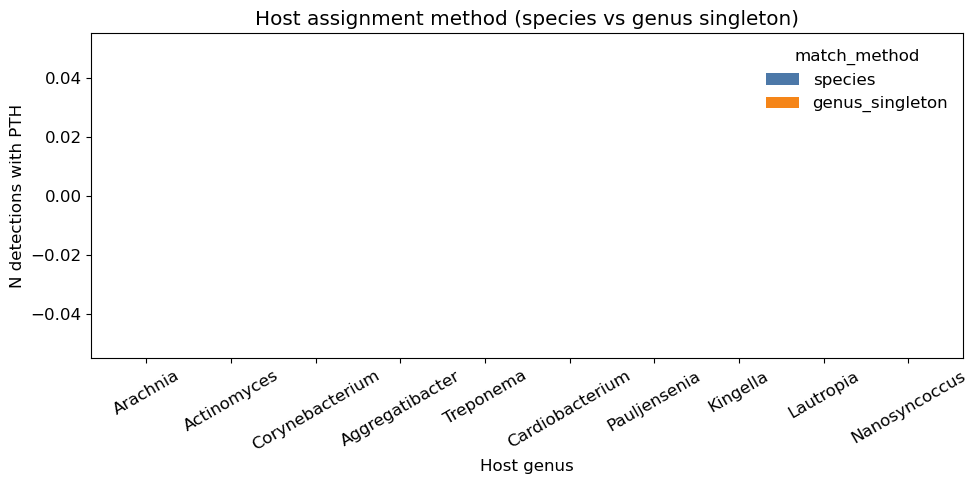

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_6/cf_pathogen_pth_results/cf_pathogen_pth_match_method.png
match_method     species  genus_singleton
pathogen                                 
Arachnia             0.0              0.0
Actinomyces          0.0              0.0
Corynebacterium      0.0              0.0
Aggregatibacter      0.0              0.0
Treponema            0.0              0.0
Cardiobacterium      0.0              0.0
Pauljensenia         0.0              0.0
Kingella             0.0              0.0
Lautropia            0.0              0.0
Nanosyncoccus        0.0              0.0


In [10]:
### Plot: match method breakdown
method_counts = (
    pth_df.group_by(["pathogen", "match_method"])
    .len()
    .to_pandas()
)
method_order = ["species", "genus_singleton"]
pivot = (
    method_counts.pivot(index="pathogen", columns="match_method", values="len")
    .reindex(genus_order)
    .fillna(0)
)
for m in method_order:
    if m not in pivot.columns:
        pivot[m] = 0
pivot = pivot[method_order]

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind="bar", stacked=True, ax=ax, color=["#4C78A8", "#F58518"], width=0.8)
ax.set_xlabel("Host genus")
ax.set_ylabel("N detections with PTH")
ax.set_title("Host assignment method (species vs genus singleton)")
ax.legend(title="match_method", frameon=False)
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
png = OUT_DIR / "cf_pathogen_pth_match_method.png"
fig.savefig(png, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", png)
print(pivot)


shape: (2, 3)
┌─────────────────┬──────┬────────────┐
│ activity_call   ┆ n    ┆ median_pth │
│ ---             ┆ ---  ┆ ---        │
│ str             ┆ u32  ┆ f64        │
╞═════════════════╪══════╪════════════╡
│ Uninducible     ┆ 1270 ┆ 0.976674   │
│ Not uninducible ┆ 3127 ┆ 1.025316   │
└─────────────────┴──────┴────────────┘


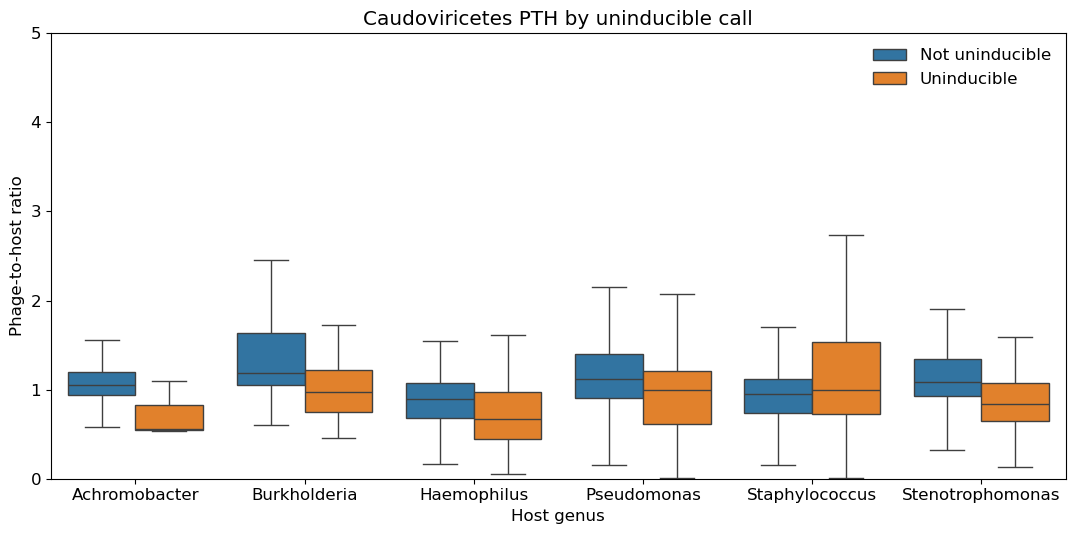

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_6/cf_pathogen_pth_results/cf_pathogen_pth_by_uninducible.png


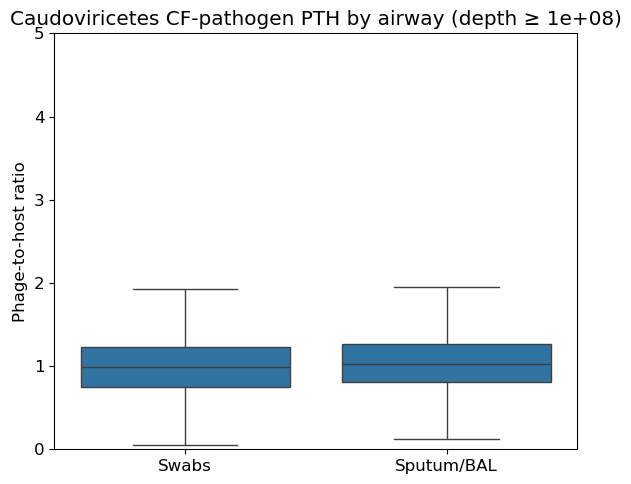

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_6/cf_pathogen_pth_results/cf_pathogen_pth_by_airway.png


In [ ]:
### Optional: PTH by uninducible call (Caudoviricetes)
if preds is None or "predicted_uninducible" not in pth_df.columns:
    print("Skipping uninducible stratification (no predictions)")
else:
    caud = (
        pth_df.filter(pl.col("ictv_class") == "Caudoviricetes")
        .filter(pl.col("predicted_uninducible").is_not_null())
        .with_columns(
            pl.when(pl.col("predicted_uninducible") == 1)
            .then(pl.lit("Uninducible"))
            .otherwise(pl.lit("Not uninducible"))
            .alias("activity_call")
        )
    )
    print(
        caud.group_by("activity_call").agg(
            [
                pl.len().alias("n"),
                pl.col("pth").median().alias("median_pth"),
            ]
        )
    )
    pdf = caud.select(["pathogen", "activity_call", "pth"]).to_pandas()
    pdf = pdf[np.isfinite(pdf["pth"]) & (pdf["pth"] > 0)]

    fig, ax = plt.subplots(figsize=(11, 5.5))
    sns.boxplot(
        data=pdf,
        x="pathogen",
        y="pth",
        hue="activity_call",
        order=genus_order,
        hue_order=["Not uninducible", "Uninducible"],
        showfliers=False,
        ax=ax,
    )
    # ax.set_yscale("log")
    ax.set_ylim(0, 5)
    ax.set_xlabel("Host genus")
    ax.set_ylabel("Phage-to-host ratio")
    ax.set_title("Caudoviricetes PTH by uninducible call")
    ax.legend(title="", frameon=False)
    fig.tight_layout()
    png = OUT_DIR / "cf_pathogen_pth_by_uninducible.png"
    fig.savefig(png, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved", png)

    # Airway stratification (deep samples)
    deep = caud.filter(pl.col("read_depth") >= DEPTH_MIN).filter(
        pl.col("airway_category").is_in(["upper_airway", "lower_airway"])
    )
    if deep.height:
        deep_pdf = (
            deep.with_columns(
                pl.col("airway_category")
                .replace({"upper_airway": "Swabs", "lower_airway": "Sputum/BAL"})
                .alias("airway_label")
            )
            .select(["airway_label", "pth"])
            .to_pandas()
        )
        deep_pdf = deep_pdf[np.isfinite(deep_pdf["pth"]) & (deep_pdf["pth"] > 0)]
        fig, ax = plt.subplots(figsize=(6, 5))
        sns.boxplot(
            data=deep_pdf,
            x="airway_label",
            y="pth",
            order=["Swabs", "Sputum/BAL"],
            showfliers=False,
            ax=ax,
        )
        # ax.set_yscale("log")
        ax.set_ylim(0, 5)
        ax.set_xlabel("")
        ax.set_ylabel("Phage-to-host ratio")
        ax.set_title(
            f"Caudoviricetes CF-pathogen PTH by airway (depth ≥ {DEPTH_MIN:.0e})"
        )
        fig.tight_layout()
        png = OUT_DIR / "cf_pathogen_pth_by_airway.png"
        fig.savefig(png, dpi=150, bbox_inches="tight")
        plt.show()
        print("Saved", png)
    else:
        print("No deep samples with airway labels for airway plot")


Removed uninducible from dominance analysis: 1,270  remaining=3,952
pathogen             thr   n_hi  dom_rate_hi   n_lo  dom_rate_lo       OR          p
------------------------------------------------------------------------------------------
Achromobacter          1     39        51.3%     10        50.0%      1.1          1
Achromobacter          2      2        50.0%     47        51.1%     0.96          1
Burkholderia           1     35        31.4%      1         0.0%      inf          1
Burkholderia           2      4        25.0%     32        31.2%     0.73          1
Burkholderia           3      1         0.0%     35        31.4%        0          1
Haemophilus            1     29         3.4%     25        16.0%     0.19       0.17
Pseudomonas            1    378        37.0%     22        27.3%      1.6      0.495
Pseudomonas            2    159        26.4%    241        43.2%     0.47   0.000685
Pseudomonas            3     78        12.8%    322        42.2%      0.2   

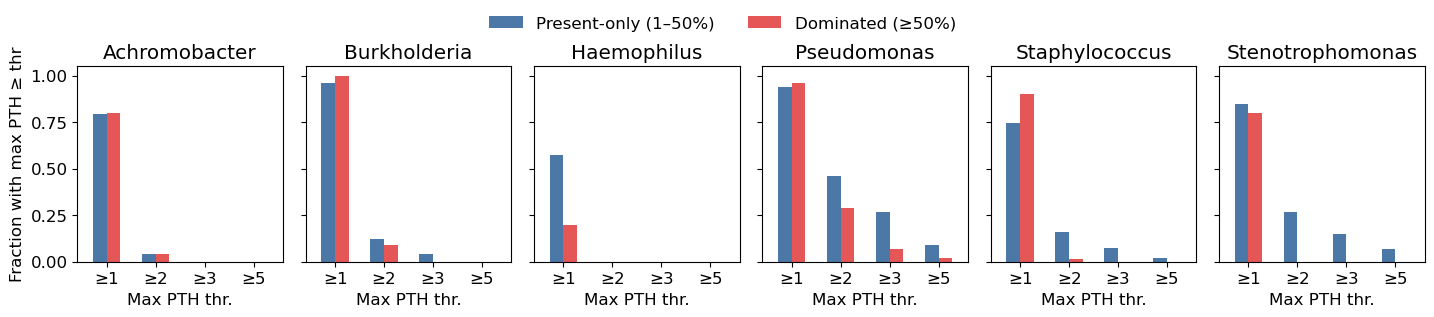

Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_6/cf_pathogen_pth_results/cf_pathogen_max_pth_vs_dominance.png


sample_id,pathogen,max_pth,median_pth,n_phages,pathogen_rel,dominated,present_only
str,str,f64,f64,u32,f64,bool,bool
"""SAMEA5554290_ERR3274613_cf""","""Staphylococcus""",1.062951,0.716516,3,5.2571,false,true
"""SAMEA14381348_ERR10814766_cf""","""Staphylococcus""",1.231018,1.0267,3,29.6457,false,true
"""SAMEA4888988_ERR2785536_cf""","""Staphylococcus""",2.134724,1.323429,2,1.9615,false,true
"""SAMN11310281_SRR8834104_cf""","""Staphylococcus""",1.107699,0.942894,2,1.6643,false,true
"""SAMN11310320_SRR8834145_cf""","""Pseudomonas""",1.133317,1.063967,2,76.8027,true,false


In [ ]:
### Max PTH vs pathogen presence / dominance
# Among samples with pathogen relative abundance ≥ 1% and ≥1 matching phage PTH,
# compare max PTH in dominated (≥50%) vs present-only (1–50%).
# Predicted-uninducible Caudoviricetes are removed before computing max PTH.
# Single plot (not faceted by ICTV class).

pth_for_dom = pth_df
if "predicted_uninducible" in pth_df.columns:
    n_before = pth_for_dom.height
    pth_for_dom = pth_for_dom.filter(
        (pl.col("predicted_uninducible").is_null())
        | (pl.col("predicted_uninducible") != 1)
    )
    print(
        f"Removed uninducible from dominance analysis: "
        f"{n_before - pth_for_dom.height:,}  remaining={pth_for_dom.height:,}"
    )

pathogen_rel = (
    bac_in_sample.group_by(["sample_id", "bac_genus"])
    .agg(pl.col("bac_rel").sum().alias("pathogen_rel"))
    .rename({"bac_genus": "pathogen"})
)

exact_species = {
    "Pseudomonas": r"s__Pseudomonas aeruginosa$",
    "Staphylococcus": r"s__Staphylococcus aureus$",
    "Haemophilus": r"s__Haemophilus influenzae$",
}
exact_parts = []
for pathogen, pat in exact_species.items():
    sub = (
        sylph_tax.filter(pl.col("sample_id").is_in(coverm_samples))
        .filter(pl.col("clade_name").str.contains(pat))
        .group_by("sample_id")
        .agg(pl.col("relative_abundance").sum().alias("pathogen_rel"))
        .with_columns(pl.lit(pathogen).alias("pathogen"))
    )
    exact_parts.append(sub)
exact_rel = pl.concat(exact_parts)

# Prefer exact species rel for PA/SA/HI; genus sum otherwise
pathogen_rel = (
    pathogen_rel.join(
        exact_rel.rename({"pathogen_rel": "exact_rel"}),
        on=["sample_id", "pathogen"],
        how="left",
    )
    .with_columns(
        pl.when(pl.col("exact_rel").is_not_null())
        .then(pl.col("exact_rel"))
        .otherwise(pl.col("pathogen_rel"))
        .alias("pathogen_rel")
    )
    .select(["sample_id", "pathogen", "pathogen_rel"])
)

# Max PTH per sample × pathogen (all remaining viruses)
sample_max = (
    pth_for_dom.group_by(["sample_id", "pathogen"])
    .agg(
        [
            pl.col("pth").max().alias("max_pth"),
            pl.col("pth").median().alias("median_pth"),
            pl.len().alias("n_phages"),
        ]
    )
    .join(pathogen_rel, on=["sample_id", "pathogen"], how="left")
    .with_columns(pl.col("pathogen_rel").fill_null(0.0))
    .filter(pl.col("pathogen_rel") >= PRESENCE_THR)
    .with_columns(
        [
            (pl.col("pathogen_rel") >= DOMINANCE_THR).alias("dominated"),
            (
                (pl.col("pathogen_rel") >= PRESENCE_THR)
                & (pl.col("pathogen_rel") < DOMINANCE_THR)
            ).alias("present_only"),
        ]
    )
)

if "genus_order" not in globals() or not genus_order:
    genus_order = sorted(sample_max["pathogen"].unique().to_list())

rows = []
print(
    f"{'pathogen':18s} {'thr':>5s} {'n_hi':>6s} "
    f"{'dom_rate_hi':>12s} {'n_lo':>6s} {'dom_rate_lo':>12s} {'OR':>8s} {'p':>10s}"
)
print("-" * 90)
for pathogen in genus_order:
    sub = sample_max.filter(pl.col("pathogen") == pathogen)
    if sub.height == 0:
        continue
    dom = sub.filter(pl.col("dominated"))
    pres = sub.filter(pl.col("present_only"))
    for thr in PTH_THRESHOLDS:
        hi = sub.filter(pl.col("max_pth") >= thr)
        lo = sub.filter(pl.col("max_pth") < thr)
        if hi.height == 0 or lo.height == 0:
            continue
        a = int(hi["dominated"].sum())
        b = hi.height - a
        c = int(lo["dominated"].sum())
        d = lo.height - c
        oddsratio, pval = stats.fisher_exact(
            [[a, b], [c, d]], alternative="two-sided"
        )
        print(
            f"{pathogen:18s} {thr:5g} {hi.height:6d} "
            f"{a / hi.height:12.1%} {lo.height:6d} {c / lo.height:12.1%} "
            f"{oddsratio:8.2g} {pval:10.3g}"
        )
        rows.append(
            {
                "pathogen": pathogen,
                "threshold": thr,
                "n_high": hi.height,
                "n_dom_high": a,
                "dom_rate_high": a / hi.height,
                "n_low": lo.height,
                "n_dom_low": c,
                "dom_rate_low": c / lo.height,
                "odds_ratio": float(oddsratio)
                if np.isfinite(oddsratio)
                else float("inf"),
                "pvalue": float(pval),
                "frac_dom_with_high_pth": float((dom["max_pth"] >= thr).mean())
                if dom.height
                else float("nan"),
                "frac_pres_with_high_pth": float((pres["max_pth"] >= thr).mean())
                if pres.height
                else float("nan"),
                "median_max_pth_dominated": float(dom["max_pth"].median())
                if dom.height
                else float("nan"),
                "median_max_pth_present_only": float(pres["max_pth"].median())
                if pres.height
                else float("nan"),
            }
        )

dom_summary = pl.DataFrame(rows) if rows else pl.DataFrame()
dom_path = OUT_DIR / "cf_pathogen_max_pth_vs_dominance.tsv.gz"
if dom_summary.height:
    dom_summary.write_csv(dom_path, separator="\t", compression="gzip")
    print("Saved", dom_path)

    n_path = len(genus_order)
    # Fixed bar width + shared x limits so bars don't stretch when a panel
    # has fewer thresholds than another.
    all_thrs = sorted(dom_summary["threshold"].unique().to_list())
    n_thr = max(len(all_thrs), 1)
    thr_to_x = {t: i for i, t in enumerate(all_thrs)}
    BAR_W = 0.28
    fig, axes = plt.subplots(
        1, n_path, figsize=(2.4 * n_path, 3.0), sharey=True, squeeze=False
    )
    axes = axes[0]
    for col_i, pathogen in enumerate(genus_order):
        ax = axes[col_i]
        sub = dom_summary.filter(pl.col("pathogen") == pathogen).sort("threshold")
        ax.set_xlim(-0.6, n_thr - 0.4)
        ax.set_ylim(0, 1.05)
        ax.set_xticks(list(range(n_thr)))
        ax.set_xticklabels([f"≥{t:g}" for t in all_thrs])
        ax.set_title(pathogen)
        ax.set_xlabel("Max PTH thr.")
        if sub.height == 0:
            ax.text(0.5, 0.5, "n/a", ha="center", va="center", transform=ax.transAxes)
            continue
        x = np.array([thr_to_x[t] for t in sub["threshold"].to_list()], dtype=float)
        ax.bar(
            x - BAR_W / 2,
            sub["frac_pres_with_high_pth"].to_list(),
            BAR_W,
            label="Present-only (1–50%)",
            color="#4C78A8",
        )
        ax.bar(
            x + BAR_W / 2,
            sub["frac_dom_with_high_pth"].to_list(),
            BAR_W,
            label="Dominated (≥50%)",
            color="#E45756",
        )
        if col_i == 0:
            ax.set_ylabel("Fraction with max PTH ≥ thr")
        else:
            ax.set_ylabel("")

    handles, labels = axes[0].get_legend_handles_labels()
    if not handles:
        # fallback if first panel had no bars
        for ax in axes:
            handles, labels = ax.get_legend_handles_labels()
            if handles:
                break
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=2,
        frameon=False,
        fontsize=12,
        bbox_to_anchor=(0.5, 1.08),
    )
    fig.tight_layout()
    png = OUT_DIR / "cf_pathogen_max_pth_vs_dominance.png"
    fig.savefig(png, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved", png)
else:
    print("No dominance summary rows")

sample_max.head()


In [ ]:
### Pseudomonas: virus taxa associated with dominance vs presence-only
# Among samples with P. aeruginosa relative abundance ≥ 1%, test whether
# presence of each Pseudomonas-infecting virus taxon (species / genus /
# family / ICTV class) associates with dominance (≥50%) vs present-only (1–50%).
# Detections: PTH-assigned Pseudomonas phages with uninducible removed.
# Test: two-sided Fisher exact; BH-FDR within each taxonomic level.

from statsmodels.stats.multitest import multipletests

PSEUDO = "Pseudomonas"
MIN_VIRUS_PRESENT = 5  # min samples with taxon detected to test

# Uninducible-filtered Pseudomonas detections
pseudo_det = pth_df.filter(pl.col("pathogen") == PSEUDO)
if "predicted_uninducible" in pseudo_det.columns:
    pseudo_det = pseudo_det.filter(
        (pl.col("predicted_uninducible").is_null())
        | (pl.col("predicted_uninducible") != 1)
    )

# P. aeruginosa relative abundance (exact species)
pa_rel = (
    sylph_tax.filter(pl.col("sample_id").is_in(coverm_samples))
    .filter(pl.col("clade_name").str.contains(r"s__Pseudomonas aeruginosa$"))
    .group_by("sample_id")
    .agg(pl.col("relative_abundance").sum().alias("pathogen_rel"))
)

pa_status = (
    pl.DataFrame({"sample_id": coverm_samples})
    .join(pa_rel, on="sample_id", how="left")
    .with_columns(pl.col("pathogen_rel").fill_null(0.0))
    .filter(pl.col("pathogen_rel") >= PRESENCE_THR)
    .with_columns(
        [
            (pl.col("pathogen_rel") >= DOMINANCE_THR).alias("dominated"),
            (
                (pl.col("pathogen_rel") >= PRESENCE_THR)
                & (pl.col("pathogen_rel") < DOMINANCE_THR)
            ).alias("present_only"),
        ]
    )
    .filter(pl.col("dominated") | pl.col("present_only"))
)

n_dom = int(pa_status["dominated"].sum())
n_pres = int(pa_status["present_only"].sum())
print(
    f"Pseudomonas cohort (rel≥{PRESENCE_THR:g}%): n={pa_status.height:,}  "
    f"dominated={n_dom:,}  present-only={n_pres:,}"
)
print(f"Pseudomonas phage detections (uninducible removed): {pseudo_det.height:,}")

level_specs = [
    ("Species", "species_cluster_id", ["ictv_class", "ictv_family", "ictv_genus", "ictv_species"]),
    ("Genus", "genus_cluster_id", ["ictv_class", "ictv_family", "ictv_genus"]),
    ("Family", "family_cluster_id", ["ictv_class", "ictv_family"]),
    ("Class", "ictv_class", []),
]

cohort_ids = set(pa_status["sample_id"].to_list())
dom_ids = set(pa_status.filter(pl.col("dominated"))["sample_id"].to_list())
pres_ids = set(pa_status.filter(pl.col("present_only"))["sample_id"].to_list())

assoc_rows = []
for level_name, id_col, annot_cols in level_specs:
    det_lvl = (
        pseudo_det.filter(pl.col(id_col).is_not_null())
        .filter(pl.col("sample_id").is_in(list(cohort_ids)))
        .select(["sample_id", id_col] + [c for c in annot_cols if c in pseudo_det.columns])
        .unique(["sample_id", id_col])
    )
    taxa = det_lvl[id_col].unique().to_list()
    for taxon in taxa:
        present_samples = set(
            det_lvl.filter(pl.col(id_col) == taxon)["sample_id"].to_list()
        )
        n_virus_present = len(present_samples)
        if n_virus_present < MIN_VIRUS_PRESENT:
            continue

        # 2×2: rows = virus present/absent; cols = dominated / present-only
        n_vp_dom = len(present_samples & dom_ids)    # virus+, dominated
        n_vp_pres = len(present_samples & pres_ids)  # virus+, present-only
        n_va_dom = n_dom - n_vp_dom                  # virus-, dominated
        n_va_pres = n_pres - n_vp_pres               # virus-, present-only
        if min(n_vp_dom + n_vp_pres, n_va_dom + n_va_pres, n_vp_dom + n_va_dom, n_vp_pres + n_va_pres) == 0:
            continue

        oddsratio, pval = stats.fisher_exact(
            [[n_vp_dom, n_vp_pres], [n_va_dom, n_va_pres]],
            alternative="two-sided",
        )
        annot = {}
        sub_annot = det_lvl.filter(pl.col(id_col) == taxon)
        for cname in annot_cols:
            if cname in sub_annot.columns:
                modes = (
                    sub_annot.select(pl.col(cname).mode().first().alias("m"))["m"]
                    .to_list()
                )
                annot[cname] = modes[0] if modes else None

        assoc_rows.append(
            {
                "taxonomic_level": level_name,
                "taxon_id": str(taxon),
                "n_virus_present": n_virus_present,
                "n_dom_given_virus": n_vp_dom,
                "n_pres_given_virus": n_vp_pres,
                "ppv_dom_given_virus": n_vp_dom / n_virus_present if n_virus_present else float("nan"),
                "dom_rate_given_absent": n_va_dom / (n_va_dom + n_va_pres)
                if (n_va_dom + n_va_pres)
                else float("nan"),
                "baseline_dom_rate": n_dom / (n_dom + n_pres),
                "odds_ratio": float(oddsratio) if np.isfinite(oddsratio) else float("inf"),
                "pvalue": float(pval),
                **annot,
            }
        )

assoc_df = pl.DataFrame(assoc_rows) if assoc_rows else pl.DataFrame()
if assoc_df.height == 0:
    print("No taxa met minimum sample criteria")
else:
    # BH-FDR within each taxonomic level
    parts = []
    for level_name, _, _ in level_specs:
        sub = assoc_df.filter(pl.col("taxonomic_level") == level_name)
        if sub.height == 0:
            continue
        reject, qvals, _, _ = multipletests(
            sub["pvalue"].to_list(), method="fdr_bh"
        )
        parts.append(
            sub.with_columns(
                [
                    pl.Series("qvalue", qvals),
                    pl.Series("significant_fdr05", reject),
                ]
            )
        )
    assoc_df = pl.concat(parts).sort(
        ["taxonomic_level", "qvalue", "pvalue"]
    )

    out = OUT_DIR / "cf_pseudomonas_taxon_dominance_association.tsv.gz"
    assoc_df.write_csv(out, separator="\t", compression="gzip")
    print("Saved", out, f"({assoc_df.height:,} tests)")

    sig = assoc_df.filter(pl.col("significant_fdr05"))
    print(f"\nSignificant associations (BH-FDR q<0.05): {sig.height}")
    if sig.height:
        show_cols = [
            c
            for c in [
                "taxonomic_level",
                "taxon_id",
                "ictv_class",
                "ictv_family",
                "ictv_genus",
                "ictv_species",
                "n_virus_present",
                "ppv_dom_given_virus",
                "odds_ratio",
                "pvalue",
                "qvalue",
            ]
            if c in sig.columns
        ]
        print(sig.select(show_cols))
    else:
        print("None at FDR < 0.05. Top hits by p-value per level:")
        for level_name, _, _ in level_specs:
            top = (
                assoc_df.filter(pl.col("taxonomic_level") == level_name)
                .sort("pvalue")
                .head(5)
            )
            if top.height:
                print(f"\n--- {level_name} ---")
                print(
                    top.select(
                        [
                            c
                            for c in [
                                "taxon_id",
                                "ictv_class",
                                "ictv_family",
                                "ictv_genus",
                                "n_virus_present",
                                "ppv_dom_given_virus",
                                "odds_ratio",
                                "pvalue",
                                "qvalue",
                            ]
                            if c in top.columns
                        ]
                    )
                )

assoc_df.head() if assoc_df.height else assoc_df


Pseudomonas cohort (rel≥1%): n=451  dominated=149  present-only=302
Pseudomonas phage detections (uninducible removed): 1,898
Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_6/cf_pathogen_pth_results/cf_pseudomonas_taxon_dominance_association.tsv.gz (156 tests)

Significant associations (BH-FDR q<0.05): 31
shape: (31, 11)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ taxonomic ┆ taxon_id  ┆ ictv_clas ┆ ictv_fami ┆ … ┆ ppv_dom_g ┆ odds_rati ┆ pvalue    ┆ qvalue   │
│ _level    ┆ ---       ┆ s         ┆ ly        ┆   ┆ iven_viru ┆ o         ┆ ---       ┆ ---      │
│ ---       ┆ str       ┆ ---       ┆ ---       ┆   ┆ s         ┆ ---       ┆ f64       ┆ f64      │
│ str       ┆           ┆ str       ┆ str       ┆   ┆ ---       ┆ f64       ┆           ┆          │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆           ┆           ┆          │
╞═══════════╪══════════

taxonomic_level,taxon_id,n_virus_present,n_dom_given_virus,n_pres_given_virus,ppv_dom_given_virus,dom_rate_given_absent,baseline_dom_rate,odds_ratio,pvalue,ictv_class,ictv_family,ictv_genus,ictv_species,qvalue,significant_fdr05
str,str,i64,i64,i64,f64,f64,f64,f64,f64,str,str,str,str,f64,bool
"""Class""","""Caudoviricetes""",354,140,214,0.39548,0.092784,0.330377,6.396677,2.2155e-9,null,null,null,null,4.4310e-9,true
"""Class""","""Faserviricetes""",328,119,209,0.362805,0.243902,0.330377,1.765072,0.018244,null,null,null,null,0.018244,true
"""Family""","""21""",72,48,24,0.666667,0.266491,0.330377,5.50495,1.7279e-10,"""Caudoviricetes""","""Peduoviridae""",null,null,2.2463e-9,true
"""Family""","""36""",212,95,117,0.448113,0.225941,0.330377,2.781735,7.5545e-7,"""Caudoviricetes""",null,null,null,0.000005,true
"""Family""","""99""",100,49,51,0.49,0.2849,0.330377,2.411569,0.000176,"""Caudoviricetes""","""Peduoviridae""",null,null,0.000763,true


In [ ]:
### Summary JSON
method_breakdown = {
    str(r["match_method"]): int(r["len"])
    for r in pth_df.group_by("match_method").len().iter_rows(named=True)
}
pathogen_breakdown = {
    str(r["pathogen"]): int(r["n_detections"])
    for r in pth_df.group_by("pathogen")
    .agg(pl.len().alias("n_detections"))
    .iter_rows(named=True)
}

summary = {
    "n_coverm_samples": len(coverm_samples),
    "n_cf_pathogen_detections": int(virus_det.height),
    "n_detections_with_pth": int(pth_df.height),
    "frac_detections_with_pth": float(pth_df.height / virus_det.height)
    if virus_det.height
    else None,
    "n_unique_virus_species": int(pth_df["species_cluster_id"].n_unique()),
    "n_unique_samples_with_pth": int(pth_df["sample_id"].n_unique()),
    "median_pth": float(pth_df["pth"].median()),
    "mean_pth": float(pth_df["pth"].mean()),
    "n_pth_ge_2": int((pth_df["pth"] >= 2).sum()),
    "n_pth_ge_3": int((pth_df["pth"] >= 3).sum()),
    "n_pth_ge_5": int((pth_df["pth"] >= 5).sum()),
    "match_method_counts": method_breakdown,
    "pathogen_detection_counts": pathogen_breakdown,
    "n_consistently_high_pth_taxa": int(high_pth.height),
    "host_matching": "species_present → genus_singleton (no most-abundant fallback)",
    "cf_pathogens": CF_GENERA,
}

summary_path = OUT_DIR / "cf_pathogen_pth_summary.json"
with open(summary_path, "w") as fh:
    json.dump(summary, fh, indent=2)
print("Saved", summary_path)
print(json.dumps(summary, indent=2))


Saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_6/cf_pathogen_pth_results/cf_pathogen_pth_summary.json
{
  "n_coverm_samples": 1809,
  "n_cf_pathogen_detections": 5657,
  "n_detections_with_pth": 5222,
  "frac_detections_with_pth": 0.9231041187908785,
  "n_unique_virus_species": 711,
  "n_unique_samples_with_pth": 948,
  "median_pth": 1.043023071916496,
  "mean_pth": 2.184172571032731,
  "n_pth_ge_2": 578,
  "n_pth_ge_3": 278,
  "n_pth_ge_5": 125,
  "match_method_counts": {
    "genus_singleton": 392,
    "species": 4830
  },
  "pathogen_detection_counts": {
    "Stenotrophomonas": 338,
    "Haemophilus": 180,
    "Staphylococcus": 2271,
    "Burkholderia": 126,
    "Pseudomonas": 2217,
    "Achromobacter": 90
  },
  "n_consistently_high_pth_taxa": 25,
  "host_matching": "species_present \u2192 genus_singleton (no most-abundant fallback)",
  "cf_pathogens": [
    "Pseudomonas",
    "Staphylococcus",
    "Haemophilus",
    "Achromobacter",


Removed uninducible: 1,270  remaining=3,952
Baseline genus (≥10 samples): 9.4%


/tmp/ipykernel_4736/2140359571.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc="upper right", fontsize=8)


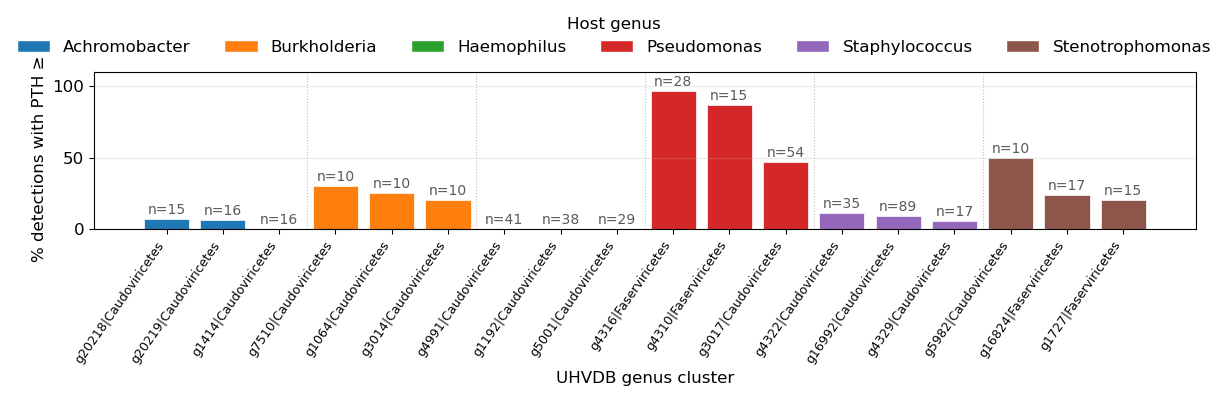

genus: 18 taxa across 6 hosts | pct elevated 0.0-96.4%
Wrote /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_6/cf_pathogen_pth_results/cf_pathogen_pth_top20_genus.tsv.gz
Wrote /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_6/cf_pathogen_pth_results/cf_pathogen_pth_top20_taxa_by_rank.png


In [ ]:
### Top-3 virus genera per host genus by elevated PTH fraction
# Group by UHVDB genus cluster IDs. Uninducible detections removed.
# Genera with ≥10 samples; within each host genus, top 3 by % detections with
# PTH ≥ 2. Vertical bars; axis labels: cluster ID | ictv_class.

MIN_SAMPLES = 10
TOP_N_PER_HOST = 3
ELEVATED_PTH = 2.0

# Exclude predicted-uninducible Caudoviricetes (keep null / not-uninducible).
pth_base = pth_df.filter(pl.col("pth").is_not_null())
if "predicted_uninducible" in pth_base.columns:
    n_before = pth_base.height
    pth_base = pth_base.filter(
        (pl.col("predicted_uninducible").is_null())
        | (pl.col("predicted_uninducible") != 1)
    )
    print(f"Removed uninducible: {n_before - pth_base.height:,}  remaining={pth_base.height:,}")

pth_tax = pth_base.with_columns(
    [
        pl.when(
            pl.col("ictv_class").is_not_null()
            & (pl.col("ictv_class").str.strip_chars() != "")
        )
        .then(pl.format("g{}|{}", pl.col("genus_cluster_id"), pl.col("ictv_class")))
        .otherwise(pl.format("g{}", pl.col("genus_cluster_id")))
        .alias("taxon_genus"),
        (pl.col("pth") >= ELEVATED_PTH).cast(pl.Int64).alias("elevated_pth"),
    ]
)


def top_taxa_by_elevated_frac_per_host(
    df: pl.DataFrame,
    taxon_col: str,
    id_col: str,
    min_samples: int = MIN_SAMPLES,
    top_n_per_host: int = TOP_N_PER_HOST,
):
    summary = (
        df.group_by([id_col, taxon_col])
        .agg(
            [
                pl.col("sample_id").n_unique().alias("n_samples"),
                pl.len().alias("n_detections"),
                pl.col("elevated_pth").sum().alias("n_elevated"),
                (pl.col("elevated_pth").mean() * 100.0).alias("pct_elevated"),
                pl.col("pth").median().alias("median_pth"),
                pl.col("host_genus").mode().first().alias("host_genus_mode"),
            ]
        )
        .filter(pl.col("n_samples") >= min_samples)
        .sort(["host_genus_mode", "pct_elevated", "n_samples"], descending=[False, True, True])
        .with_columns(
            pl.col("pct_elevated")
            .rank(method="ordinal", descending=True)
            .over("host_genus_mode")
            .alias("rank_within_host")
        )
        .filter(pl.col("rank_within_host") <= top_n_per_host)
        .sort(["host_genus_mode", "pct_elevated", "n_samples"], descending=[False, True, True])
        .with_row_index("rank", offset=1)
    )
    return summary


all_hosts = sorted(pth_tax["host_genus"].unique().to_list())
host_colors = {g: CF_HOST_COLORS.get(g, c) for g, c in zip(
    all_hosts, sns.color_palette("tab10", n_colors=max(len(all_hosts), 1))
)}
# Prefer fixed CF pathogen colors when available
host_colors = {
    g: CF_HOST_COLORS[g] if g in CF_HOST_COLORS else host_colors[g]
    for g in all_hosts
}

# Baseline among ≥10-sample genus clusters (detection-row % PTH≥2)
keep = (
    pth_tax.group_by("genus_cluster_id")
    .agg(pl.col("sample_id").n_unique().alias("n_samples"))
    .filter(pl.col("n_samples") >= MIN_SAMPLES)
    .select("genus_cluster_id")
)
sub = pth_tax.join(keep, on="genus_cluster_id", how="inner")
baseline = 100.0 * float(sub["elevated_pth"].mean())
print(f"Baseline genus (≥{MIN_SAMPLES} samples): {baseline:.1f}%")

summary = top_taxa_by_elevated_frac_per_host(
    pth_tax, "taxon_genus", "genus_cluster_id"
)

labels = []
for t in summary["taxon_genus"].to_list():
    s = str(t)
    labels.append(s if len(s) <= 28 else s[:25] + "…")
pcts = summary["pct_elevated"].to_list()
ns = summary["n_samples"].to_list()
hosts = summary["host_genus_mode"].to_list()
colors = [host_colors[h] for h in hosts]
x = list(range(len(labels)))

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.bar(x, pcts, color=colors, edgecolor="white", linewidth=0.5, width=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=55, ha="right", fontsize=9)
for xi, pct, n in zip(x, pcts, ns):
    ax.text(
        xi,
        float(pct) + 1.5,
        f"n={int(n)}",
        va="bottom",
        ha="center",
        fontsize=10,
        color="0.35",
        rotation=0,
    )
for xi in range(1, len(hosts)):
    if hosts[xi] != hosts[xi - 1]:
        ax.axvline(xi - 0.5, color="0.75", linewidth=0.8, linestyle=":")
ax.set_ylabel("% detections with PTH ≥ 2")
ax.set_xlabel("UHVDB genus cluster")
ax.set_ylim(0, 110)
ax.grid(alpha=0.25, axis="y")
ax.legend(frameon=False, loc="upper right", fontsize=8)

handles = [Patch(facecolor=host_colors[h], edgecolor="white", label=h) for h in all_hosts]
fig.legend(
    handles=handles,
    title="Host genus",
    loc="upper center",
    ncol=min(len(all_hosts), 6),
    bbox_to_anchor=(0.5, 1.15),
    frameon=False,
)

plt.tight_layout()
fig.savefig(OUT_DIR / "cf_pathogen_pth_top20_taxa_by_rank.png", dpi=200, bbox_inches="tight")
plt.show()

out = OUT_DIR / "cf_pathogen_pth_top20_genus.tsv.gz"
summary.write_csv(out, separator="\t", compression="gzip")
print(
    f"genus: {summary.height} taxa across {summary['host_genus_mode'].n_unique()} hosts | "
    f"pct elevated {summary['pct_elevated'].min():.1f}-{summary['pct_elevated'].max():.1f}%"
)
print("Wrote", out)
print("Wrote", OUT_DIR / "cf_pathogen_pth_top20_taxa_by_rank.png")


## Longitudinal PTH trajectories (expanded cohort)

Includes **sputum and oropharyngeal** longitudinal collections with span **>30 days**, ≥2 timepoints, and a CF pathogen detected at **≥2 timepoints**. Uses current species→genus-singleton PTH. Drops always-uninducible subject×species series and viruses with **<50%** persistence among host-positive timepoints. LiPuma enriched `L*` subjects excluded from plots. TIP-specific panels remain in a separate section below.

In [29]:
### Expanded longitudinal cohort + always-uninducible + ≥50% host-positive persistence
from matplotlib.lines import Line2D

SAMPLESHEET = FIG_6 / "cf_longitudinal_samplesheet.csv"

samplesheet = (
    pl.read_csv(SAMPLESHEET)
    .with_columns(
        pl.when(
            pl.col("sample_type").str.to_lowercase().str.contains("oropharyn")
            | (pl.col("sample_type").str.to_lowercase() == "swab")
        )
        .then(pl.lit("oropharyngeal"))
        .when(
            pl.col("sample_type").str.to_lowercase().str.contains("sputum")
            | (pl.col("sample_type") == "SP")
        )
        .then(pl.lit("sputum"))
        .otherwise(pl.col("sample_type"))
        .alias("sample_type_norm")
    )
    .with_columns(
        pl.when(pl.col("condition").is_in(["no exacerbation", "normal", "Pre TIP", "Post TIP"]))
        .then(pl.lit("stable"))
        .when(pl.col("condition").is_in(["exacerbation", "ex", "pe"]))
        .then(pl.lit("exacerbation"))
        .when(pl.col("condition") == "On TIP")
        .then(pl.lit("On TIP"))
        .otherwise(pl.lit("Unknown"))
        .alias("clinical_status")
    )
)

read_depth_ss = (
    pl.read_csv(READ_DEPTH, separator="\t", has_header=False)
    .rename({"column_1": "sample_id", "column_2": "num_bp"})
)
samplesheet_w_depth = samplesheet.join(
    read_depth_ss, left_on="sample", right_on="sample_id", how="left"
)

# Eligible samples: sputum/OP, depth filter, parseable calendar or week timepoints
dated = (
    samplesheet_w_depth.filter(pl.col("sample_type_norm").is_in(["sputum", "oropharyngeal"]))
    .filter(pl.col("num_bp") >= DEPTH_MIN)
    .filter(pl.col("timepoint").str.contains(r"^20\d{2}-\d{2}-\d{2}$"))
    .with_columns(
        [
            pl.col("timepoint").str.to_date("%Y-%m-%d").alias("tp_date"),
            pl.lit(None).cast(pl.Int64).alias("tp_week"),
            pl.lit("date").alias("tp_kind"),
        ]
    )
)
weeks = (
    samplesheet_w_depth.filter(pl.col("sample_type_norm").is_in(["sputum", "oropharyngeal"]))
    .filter(pl.col("num_bp") >= DEPTH_MIN)
    .filter(pl.col("timepoint").str.contains(r"^\d+$"))
    .with_columns(
        [
            pl.lit(None).cast(pl.Date).alias("tp_date"),
            pl.col("timepoint").cast(pl.Int64).alias("tp_week"),
            pl.lit("week").alias("tp_kind"),
        ]
    )
)
elig = pl.concat([dated, weeks], how="diagonal_relaxed")

span_date = (
    elig.filter(pl.col("tp_kind") == "date")
    .unique(["coassembly_group", "tp_date"])
    .group_by("coassembly_group")
    .agg(
        [
            (pl.col("tp_date").max() - pl.col("tp_date").min())
            .dt.total_days()
            .alias("span_days"),
            pl.len().alias("n_tp"),
        ]
    )
)
span_week = (
    elig.filter(pl.col("tp_kind") == "week")
    .unique(["coassembly_group", "tp_week"])
    .group_by("coassembly_group")
    .agg(
        [
            ((pl.col("tp_week").max() - pl.col("tp_week").min()) * 7).alias("span_days"),
            pl.len().alias("n_tp"),
        ]
    )
)
long_groups = set(
    pl.concat([span_date, span_week], how="diagonal_relaxed")
    .filter((pl.col("span_days") > 50) & (pl.col("n_tp") >= 2))["coassembly_group"]
    .to_list()
)

ss_long = (
    elig.filter(pl.col("coassembly_group").is_in(long_groups))
    .with_columns(
        pl.when(pl.col("tp_date").is_not_null())
        .then(pl.col("tp_date").cast(pl.Utf8))
        .otherwise(pl.col("tp_week").cast(pl.Utf8))
        .alias("tp_key")
    )
)

# Host-positive samples (exact species for PA/SA/HI; genus otherwise)
_exact_host_patterns = {
    "Pseudomonas": r"s__Pseudomonas aeruginosa$",
    "Staphylococcus": r"s__Staphylococcus aureus$",
    "Haemophilus": r"s__Haemophilus influenzae$",
}
host_present_genus = (
    bac_in_sample.group_by(["sample_id", "bac_genus"])
    .agg(pl.col("bac_rel").sum().alias("host_rel"))
    .filter(pl.col("host_rel") > 0)
    .rename({"bac_genus": "host_genus"})
    .select(["sample_id", "host_genus"])
)
_exact_present_parts = []
for _pathogen, _pat in _exact_host_patterns.items():
    _exact_present_parts.append(
        sylph_tax.filter(pl.col("sample_id").is_in(coverm_samples))
        .filter(pl.col("clade_name").str.contains(_pat))
        .filter(pl.col("relative_abundance") > 0)
        .select(["sample_id"])
        .unique()
        .with_columns(pl.lit(_pathogen).alias("host_genus"))
    )
host_present = (
    host_present_genus.join(
        pl.concat(_exact_present_parts).with_columns(pl.lit(True).alias("_exact")),
        on=["sample_id", "host_genus"],
        how="left",
    )
    .filter(
        (~pl.col("host_genus").is_in(list(_exact_host_patterns.keys())))
        | pl.col("_exact").fill_null(False)
    )
    .select(["sample_id", "host_genus"])
    .unique()
)

# Require CF pathogen at ≥2 timepoints within subject
pathogen_multi_tp = (
    host_present.join(
        ss_long.select(["sample", "coassembly_group", "tp_key"]),
        left_on="sample_id",
        right_on="sample",
        how="inner",
    )
    .unique(["coassembly_group", "host_genus", "tp_key"])
    .group_by(["coassembly_group", "host_genus"])
    .len()
    .filter(pl.col("len") >= 2)
    .select(["coassembly_group", "host_genus"])
)
subj_keep = set(pathogen_multi_tp["coassembly_group"].unique().to_list())
ss_long = ss_long.filter(pl.col("coassembly_group").is_in(subj_keep)).with_columns(
    pl.when(pl.col("tp_date").is_not_null())
    .then(
        (pl.col("tp_date") - pl.col("tp_date").min().over("coassembly_group"))
        .dt.total_days()
    )
    .otherwise(
        (pl.col("tp_week") - pl.col("tp_week").min().over("coassembly_group")) * 7
    )
    .alias("day_after_min")
)

long_pth_raw = (
    pth_df.join(
        ss_long.select(
            [
                "sample",
                "coassembly_group",
                "clinical_status",
                "day_after_min",
                "tp_key",
                "sample_type_norm",
                "bioproject",
            ]
        ),
        left_on="sample_id",
        right_on="sample",
        how="inner",
    ).filter(pl.col("pth").is_not_null())
)

always_uninducible = (
    long_pth_raw.group_by(["coassembly_group", "species_cluster_id"])
    .agg(
        (pl.col("predicted_uninducible").fill_null(0) == 1)
        .all()
        .alias("always_uninducible")
    )
    .filter(pl.col("always_uninducible"))
    .select(["coassembly_group", "species_cluster_id"])
)
long_pth_filt = long_pth_raw.join(
    always_uninducible, on=["coassembly_group", "species_cluster_id"], how="anti"
)

pathogen_virus_hosts = pth_df.select(
    ["species_cluster_id", "host_genus", "pathogen"]
).unique(subset=["species_cluster_id"], keep="first")

host_tp_per_group = (
    host_present.join(
        ss_long.select(["sample", "coassembly_group", "tp_key"]),
        left_on="sample_id",
        right_on="sample",
        how="inner",
    )
    .group_by(["coassembly_group", "host_genus"])
    .agg(pl.col("tp_key").n_unique().alias("n_host_timepoints"))
)
virus_on_host = (
    coverm_det.join(
        ss_long.select(["sample", "coassembly_group", "tp_key"]),
        left_on="sample_id",
        right_on="sample",
        how="inner",
    )
    .join(pathogen_virus_hosts, on="species_cluster_id", how="inner")
    .join(host_present, on=["sample_id", "host_genus"], how="inner")
    .group_by(["coassembly_group", "species_cluster_id", "host_genus", "pathogen"])
    .agg(pl.col("tp_key").n_unique().alias("n_detected"))
)
pathogen_virus_persistence = (
    virus_on_host.join(
        host_tp_per_group, on=["coassembly_group", "host_genus"], how="inner"
    )
    .with_columns(
        (pl.col("n_detected") / pl.col("n_host_timepoints")).alias("persistence")
    )
    .filter(pl.col("n_host_timepoints") > 0)
    .filter(~pl.col("coassembly_group").str.starts_with("L"))
)
pathogen_virus_persistence.write_csv(
    OUT_DIR / "cf_longitudinal_pathogen_virus_persistence.tsv.gz",
    separator="\t",
    compression="gzip",
)

virus_persistence = pathogen_virus_persistence.filter(pl.col("persistence") >= 0.5)
n_before_persist = long_pth_filt.height
long_pth_filt = long_pth_filt.join(
    virus_persistence.select(["coassembly_group", "species_cluster_id", "persistence"]),
    on=["coassembly_group", "species_cluster_id"],
    how="inner",
)

long_pth_df = (
    long_pth_filt.filter(~pl.col("coassembly_group").str.starts_with("L"))
    .join(pathogen_multi_tp, on=["coassembly_group", "host_genus"], how="inner")
    .select(
        [
            "coassembly_group",
            "host_genus",
            "species_cluster_id",
            "pth",
            "day_after_min",
            "clinical_status",
            "sample_id",
            "predicted_uninducible",
            "persistence",
            "sample_type_norm",
        ]
    )
)
long_pth_df.write_csv(
    OUT_DIR / "cf_longitudinal_pth_trajectories.tsv.gz",
    separator="\t",
    compression="gzip",
)

print(f"longitudinal groups (>30d, pathogen ≥2 tp): {len(subj_keep)}")
print(f"detections in cohort: {long_pth_raw.height}")
print(f"always-uninducible subject×species dropped: {always_uninducible.height}")
print(
    f"after ≥50% host-positive persistence: {long_pth_filt.height} "
    f"(dropped {n_before_persist - long_pth_filt.height})"
)
print(
    f"plot detections: {long_pth_df.height} | "
    f"subjects: {long_pth_df['coassembly_group'].n_unique()} | "
    f"species: {long_pth_df['species_cluster_id'].n_unique()}"
)
display(
    long_pth_df.group_by("sample_type_norm").agg(
        [
            pl.col("coassembly_group").n_unique().alias("n_subjects"),
            pl.len().alias("n_detections"),
        ]
    )
)
display(long_pth_df.group_by("host_genus").len().sort("len", descending=True))

longitudinal groups (>30d, pathogen ≥2 tp): 36
detections in cohort: 1156
always-uninducible subject×species dropped: 160
after ≥50% host-positive persistence: 576 (dropped 314)
plot detections: 547 | subjects: 32 | species: 134


sample_type_norm,n_subjects,n_detections
str,u32,u32
"""oropharyngeal""",14,162
"""sputum""",21,385


host_genus,len
str,u32
"""Pseudomonas""",380
"""Staphylococcus""",118
"""Achromobacter""",24
"""Haemophilus""",17
"""Stenotrophomonas""",8


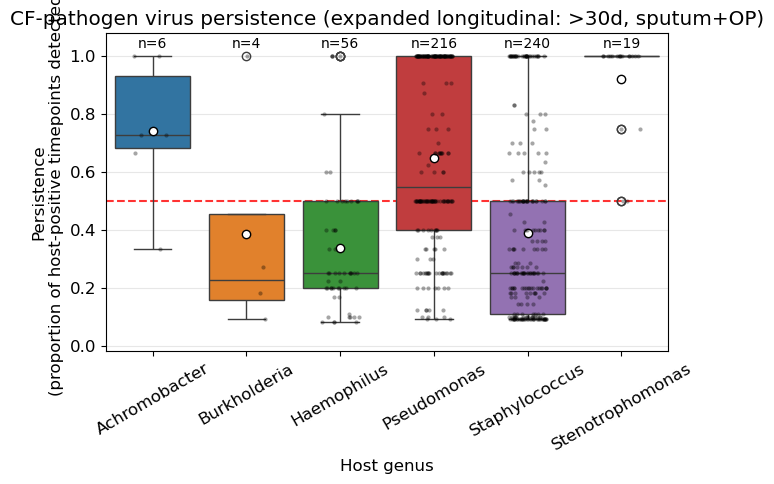

subject×species: 541 | ≥50% persistence: 281 (51.9%)
Wrote /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_6/cf_pathogen_pth_results/cf_longitudinal_pathogen_virus_persistence.png


In [30]:
### Plot: persistence of CF-pathogen virus species (longitudinal cohort)
# Unit: subject × virus species.
# Persistence = CoverM-detected host-positive timepoints / host-positive timepoints.
# Horizontal line at 0.5 marks the filter used for the PTH trajectory plot below.

persist_plot_df = pathogen_virus_persistence.filter(pl.col("persistence").is_not_null())
persist_pd = persist_plot_df.to_pandas()

order = sorted(persist_plot_df["host_genus"].unique().to_list())
counts = (
    persist_plot_df.group_by("host_genus")
    .len()
    .sort("host_genus")
)
count_map = {r["host_genus"]: r["len"] for r in counts.iter_rows(named=True)}

genus_colors = {g: CF_HOST_COLORS[g] for g in order if g in CF_HOST_COLORS}

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(
    data=persist_pd,
    x="host_genus",
    y="persistence",
    order=order,
    hue="host_genus",
    hue_order=order,
    palette=genus_colors,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 6,
    },
    legend=False,
    ax=ax,
)
sns.stripplot(
    data=persist_pd,
    x="host_genus",
    y="persistence",
    order=order,
    color="black",
    alpha=0.35,
    size=3,
    jitter=0.2,
    ax=ax,
)

ax.axhline(0.5, color="red", linestyle="--", linewidth=1.5, alpha=0.8, zorder=0)
ax.set_ylim(-0.02, 1.08)
ax.set_xlabel("Host genus")
ax.set_ylabel("Persistence\n(proportion of host-positive timepoints detected)")
ax.set_title("CF-pathogen virus persistence (expanded longitudinal: >30d, sputum+OP)")
ax.tick_params(axis="x", rotation=30)
ax.grid(alpha=0.3, axis="y")

y_top = 1.02
for i, genus in enumerate(order):
    ax.text(i, y_top, f"n={count_map[genus]}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
fig.savefig(
    OUT_DIR / "cf_longitudinal_pathogen_virus_persistence.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

n_ge_50 = persist_plot_df.filter(pl.col("persistence") >= 0.5).height
print(
    f"subject×species: {persist_plot_df.height} | "
    f"≥50% persistence: {n_ge_50} ({n_ge_50 / persist_plot_df.height:.1%})"
)
print("Wrote", OUT_DIR / "cf_longitudinal_pathogen_virus_persistence.png")

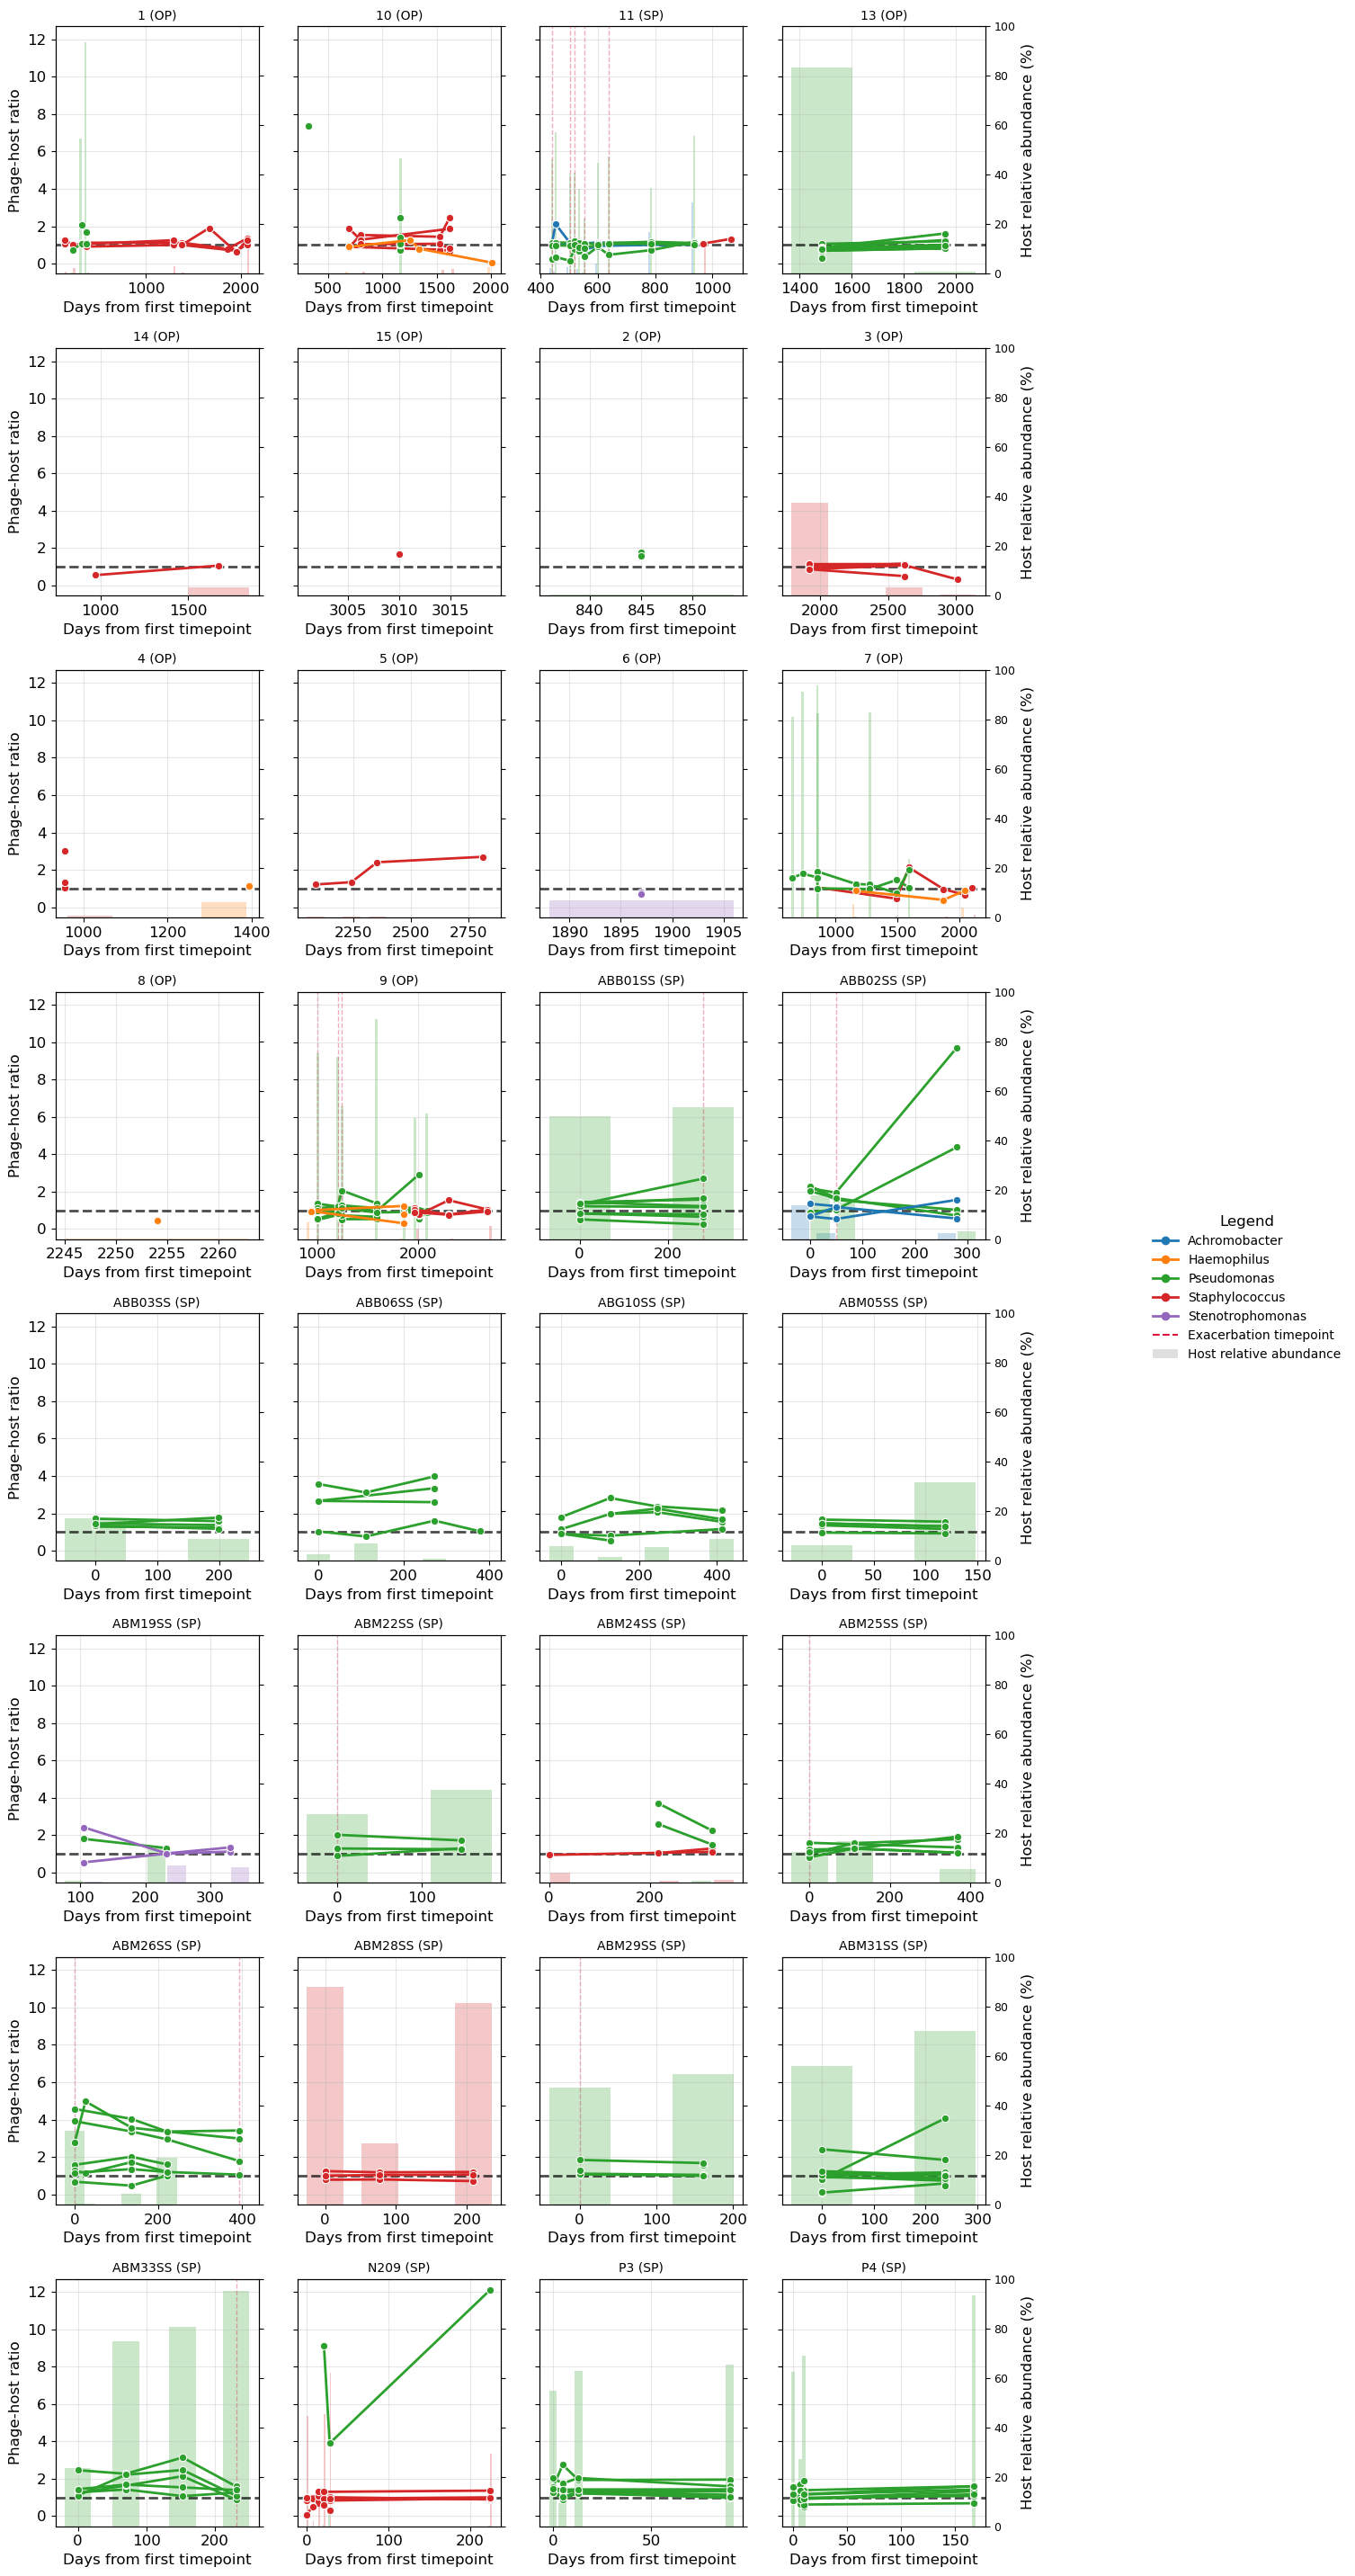

plot detections: 547 | subjects: 32 | species: 134
Wrote /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_6/cf_pathogen_pth_results/cf_longitudinal_pth_trajectories.png


In [31]:
### Lineplot: all PTH trajectories + host relative abundance bars
# One line per virus species (hue = host genus). Twin-axis bars = host relative
# abundance (exact species for PA/SA/HI; genus sum otherwise).

exact_species = {
    "Pseudomonas": r"s__Pseudomonas aeruginosa$",
    "Staphylococcus": r"s__Staphylococcus aureus$",
    "Haemophilus": r"s__Haemophilus influenzae$",
}

host_rel_genus = (
    bac_in_sample.group_by(["sample_id", "bac_genus"])
    .agg(pl.col("bac_rel").sum().alias("host_rel"))
    .rename({"bac_genus": "host_genus"})
)

exact_parts = []
for pathogen, pat in exact_species.items():
    sub = (
        sylph_tax.filter(pl.col("sample_id").is_in(coverm_samples))
        .filter(pl.col("clade_name").str.contains(pat))
        .group_by("sample_id")
        .agg(pl.col("relative_abundance").sum().alias("host_rel"))
        .with_columns(pl.lit(pathogen).alias("host_genus"))
    )
    exact_parts.append(sub)
host_rel_exact = pl.concat(exact_parts)

host_rel = (
    host_rel_genus.join(
        host_rel_exact.rename({"host_rel": "exact_rel"}),
        on=["sample_id", "host_genus"],
        how="left",
    )
    .with_columns(
        pl.when(pl.col("exact_rel").is_not_null())
        .then(pl.col("exact_rel"))
        .otherwise(pl.col("host_rel"))
        .alias("host_rel")
    )
    .select(["sample_id", "host_genus", "host_rel"])
)

# Host-rel bars: one value per subject × genus × timepoint (not per virus)
host_rel_plot = (
    long_pth_df.select(
        ["coassembly_group", "host_genus", "sample_id", "day_after_min", "clinical_status"]
    )
    .unique()
    .join(host_rel, on=["sample_id", "host_genus"], how="left")
)

long_pth_df_pd = long_pth_df.to_pandas()
type_map = {
    r["coassembly_group"]: r["sample_type_norm"]
    for r in long_pth_df.group_by("coassembly_group")
    .agg(pl.col("sample_type_norm").mode().first().alias("sample_type_norm"))
    .iter_rows(named=True)
}

host_rel_pd = host_rel_plot.to_pandas()

coassembly_groups = sorted(long_pth_df["coassembly_group"].unique().to_list())
n_groups = len(coassembly_groups)
n_cols = 4
n_rows = max((n_groups + n_cols - 1) // n_cols, 1)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.6 * n_rows), sharey=True)
axes = np.atleast_1d(axes).ravel()

all_genera = sorted(long_pth_df["host_genus"].unique().to_list())
genus_colors = {g: CF_HOST_COLORS[g] for g in all_genera if g in CF_HOST_COLORS}

host_rel_ymax = float(host_rel_plot["host_rel"].drop_nulls().max() or 100.0)
host_rel_ymax = max(host_rel_ymax * 1.05, 1.0)

for idx, group in enumerate(coassembly_groups):
    ax = axes[idx]
    group_data = long_pth_df_pd[long_pth_df_pd["coassembly_group"] == group].copy()
    group_host = host_rel_pd[host_rel_pd["coassembly_group"] == group].copy()

    st = type_map.get(group, "")
    st_short = "OP" if st == "oropharyngeal" else ("SP" if st == "sputum" else st)

    if len(group_data) == 0:
        ax.text(
            0.5,
            0.5,
            f"No data for {group}",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        ax.set_title(f"{group} ({st_short})", fontsize=10)
        continue

    ex_days = sorted(
        group_data.loc[group_data["clinical_status"] == "exacerbation", "day_after_min"]
        .dropna()
        .unique()
    )
    for day in ex_days:
        ax.axvline(day, color="crimson", linestyle="--", linewidth=1, alpha=0.35, zorder=0)

    ax2 = ax.twinx()
    days = np.sort(group_host["day_after_min"].dropna().unique())
    if len(days) > 1:
        base_width = float(np.median(np.diff(days))) * 0.55
    else:
        base_width = 20.0
    genera_here = sorted(group_host["host_genus"].dropna().unique())
    n_gen_here = max(len(genera_here), 1)
    bar_width = base_width / n_gen_here

    for gi, g in enumerate(genera_here):
        gdf = group_host[group_host["host_genus"] == g].sort_values("day_after_min")
        dodge = (gi - (n_gen_here - 1) / 2.0) * bar_width
        ax2.bar(
            gdf["day_after_min"].to_numpy() + dodge,
            gdf["host_rel"].fillna(0.0).to_numpy(),
            width=bar_width * 0.9,
            color=genus_colors[g],
            alpha=0.25,
            zorder=1,
            linewidth=0,
        )

    sns.lineplot(
        data=group_data,
        x="day_after_min",
        y="pth",
        marker="o",
        markersize=6,
        linewidth=2,
        hue="host_genus",
        style="species_cluster_id",
        palette=genus_colors,
        dashes=False,
        ax=ax,
        legend=False,
        zorder=3,
    )

    ax.axhline(1, color="black", linestyle="--", linewidth=2, alpha=0.7, zorder=2)
    ax.set_xlabel("Days from first timepoint")
    st = type_map.get(group, "")
    st_short = "OP" if st == "oropharyngeal" else ("SP" if st == "sputum" else st)
    ax.set_title(f"{group} ({st_short})", fontsize=10)
    ax.grid(alpha=0.3, zorder=0)
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
    ax2.set_ylim(0, host_rel_ymax)
    ax2.tick_params(axis="y", labelsize=9)

    if idx % n_cols == 0:
        ax.set_ylabel("Phage-host ratio")
    else:
        ax.set_ylabel("")
        ax.tick_params(axis="y", labelleft=False)

    if idx % n_cols == n_cols - 1 or idx == n_groups - 1:
        ax2.set_ylabel("Host relative abundance (%)")
    else:
        ax2.set_ylabel("")
        ax2.tick_params(axis="y", labelright=False)

for idx in range(len(coassembly_groups), len(axes)):
    axes[idx].set_visible(False)

legend_handles = [
    Line2D([0], [0], color=genus_colors[g], lw=2, marker="o", markersize=6, label=g)
    for g in all_genera
]
legend_handles.append(
    Line2D(
        [0],
        [0],
        color="crimson",
        lw=1.5,
        linestyle="--",
        label="Exacerbation timepoint",
    )
)
legend_handles.append(
    plt.Rectangle((0, 0), 1, 1, fc="grey", alpha=0.25, label="Host relative abundance")
)
fig.legend(
    handles=legend_handles,
    title="Legend",
    loc="center right",
    bbox_to_anchor=(1.08, 0.5),
    fontsize=10,
    title_fontsize=12,
    frameon=False,
)

plt.tight_layout(rect=[0, 0, 0.84, 1])
fig.savefig(
    OUT_DIR / "cf_longitudinal_pth_trajectories.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()
print(
    f"plot detections: {long_pth_df.height} | "
    f"subjects: {long_pth_df['coassembly_group'].n_unique()} | "
    f"species: {long_pth_df['species_cluster_id'].n_unique()}"
)
print("Wrote", OUT_DIR / "cf_longitudinal_pth_trajectories.png")

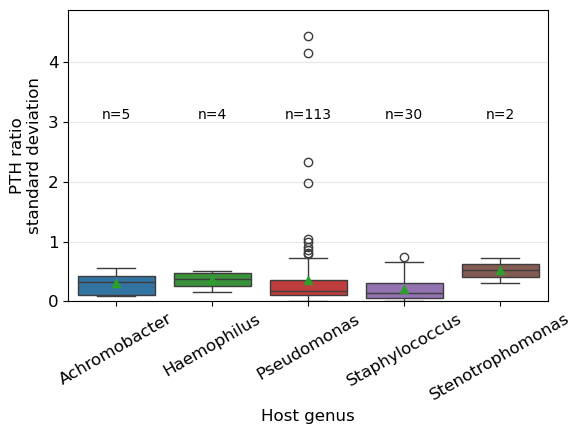

subject×species with ≥2 timepoints: 154 | hosts: 5
Overall median PTH SD: 0.17545240176544824


host_genus,n,median_sd,mean_sd,median_n_days
str,u32,f64,f64,f64
"""Pseudomonas""",113,0.175684,0.355926,3.0
"""Staphylococcus""",30,0.149667,0.206914,3.0
"""Achromobacter""",5,0.323497,0.300693,3.0
"""Haemophilus""",4,0.373882,0.354309,2.5
"""Stenotrophomonas""",2,0.517995,0.517995,3.0


Wrote /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_6/cf_pathogen_pth_results/cf_longitudinal_pth_sd_by_host.png


In [41]:
### Plot: PTH standard deviation by host genus
# Among phages detected at ≥2 timepoints within a subject (current longitudinal
# filters: always-uninducible removed, ≥50% host-positive persistence).

pth_sd_by_species = (
    long_pth_df.filter(pl.col("pth").is_not_null())
    .group_by(["coassembly_group", "species_cluster_id", "host_genus"])
    .agg(
        [
            pl.col("day_after_min").n_unique().alias("n_days"),
            pl.col("pth").count().alias("n_obs"),
            pl.col("pth").mean().alias("pth_mean"),
            pl.col("pth").std().alias("pth_sd"),
        ]
    )
    .filter(pl.col("n_days") >= 2)
    .filter(pl.col("pth_sd").is_not_null())
    .with_columns((pl.col("pth_sd") / pl.col("pth_mean")).alias("pth_cv"))
)

pth_sd_by_species.write_csv(
    OUT_DIR / "cf_longitudinal_pth_sd_by_species.tsv.gz",
    separator="\t",
    compression="gzip",
)

order = sorted(pth_sd_by_species["host_genus"].unique().to_list())
counts = {
    r["host_genus"]: r["len"]
    for r in pth_sd_by_species.group_by("host_genus").len().iter_rows(named=True)
}
genus_colors = {g: CF_HOST_COLORS[g] for g in order if g in CF_HOST_COLORS}
sd_pd = pth_sd_by_species.to_pandas()

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(
    data=sd_pd,
    x="host_genus",
    y="pth_sd",
    order=order,
    hue="host_genus",
    hue_order=order,
    palette=genus_colors,
    showmeans=True,
    legend=False,
    ax=ax,
)

y_max = float(pth_sd_by_species["pth_sd"].max())
y_pad = 0.05 * y_max if y_max > 0 else 0.05
for i, genus in enumerate(order):
    ax.text(i, 3, f"n={counts[genus]}", ha="center", va="bottom", fontsize=10)

ax.set_ylabel("PTH ratio\nstandard deviation")
ax.set_xlabel("Host genus")
ax.set_ylim(bottom=0, top=y_max + 2 * y_pad)
ax.tick_params(axis="x", rotation=30)
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
fig.savefig(
    OUT_DIR / "cf_longitudinal_pth_sd_by_host.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print(
    f"subject×species with ≥2 timepoints: {pth_sd_by_species.height} | "
    f"hosts: {pth_sd_by_species['host_genus'].n_unique()}"
)
print(
    "Overall median PTH SD:",
    float(pth_sd_by_species["pth_sd"].median()),
)
display(
    pth_sd_by_species.group_by("host_genus")
    .agg(
        [
            pl.len().alias("n"),
            pl.col("pth_sd").median().alias("median_sd"),
            pl.col("pth_sd").mean().alias("mean_sd"),
            pl.col("n_days").median().alias("median_n_days"),
        ]
    )
    .sort("n", descending=True)
)
print("Wrote", OUT_DIR / "cf_longitudinal_pth_sd_by_host.png")

## TIP cohort PTH (figure_6e recreation)

PRJNA530252 only (weeks 0–5). Uses current species→genus-singleton PTH, drops always-uninducible subject×species series, and keeps viruses with ≥50% persistence among **host-positive** TIP timepoints. Includes faceted trajectories (with host abundance bars), On vs Off TIP boxplot, and PTH SD by host.

In [43]:
### TIP cohort table (current PTH + filters)
from matplotlib.patches import Patch

TIP_WEEKS = ["0", "1", "2", "3", "4", "5"]

ss_tip = (
    pl.read_csv(FIG_6 / "cf_longitudinal_samplesheet.csv")
    .filter(pl.col("bioproject") == "PRJNA530252")
    .filter(pl.col("timepoint").is_in(TIP_WEEKS))
    .with_columns(
        pl.when(pl.col("condition").is_in(["Pre TIP", "Post TIP"]))
        .then(pl.lit("Off TIP"))
        .when(pl.col("condition") == "On TIP")
        .then(pl.lit("On TIP"))
        .otherwise(pl.col("condition"))
        .alias("tip_status")
    )
    .select(["sample", "coassembly_group", "timepoint", "tip_status", "condition"])
)

tip_pth_raw = (
    pth_df.join(ss_tip, left_on="sample_id", right_on="sample", how="inner")
    .filter(pl.col("pth").is_not_null())
)

tip_always_uninducible = (
    tip_pth_raw.group_by(["coassembly_group", "species_cluster_id"])
    .agg(
        (pl.col("predicted_uninducible").fill_null(0) == 1)
        .all()
        .alias("always_uninducible")
    )
    .filter(pl.col("always_uninducible"))
    .select(["coassembly_group", "species_cluster_id"])
)
tip_filt = tip_pth_raw.join(
    tip_always_uninducible, on=["coassembly_group", "species_cluster_id"], how="anti"
)

_exact_host_patterns = {
    "Pseudomonas": r"s__Pseudomonas aeruginosa$",
    "Staphylococcus": r"s__Staphylococcus aureus$",
    "Haemophilus": r"s__Haemophilus influenzae$",
}

host_present_genus = (
    bac_in_sample.group_by(["sample_id", "bac_genus"])
    .agg(pl.col("bac_rel").sum().alias("host_rel"))
    .filter(pl.col("host_rel") > 0)
    .rename({"bac_genus": "host_genus"})
    .select(["sample_id", "host_genus"])
)
_exact_present_parts = []
for _pathogen, _pat in _exact_host_patterns.items():
    _exact_present_parts.append(
        sylph_tax.filter(pl.col("sample_id").is_in(coverm_samples))
        .filter(pl.col("clade_name").str.contains(_pat))
        .filter(pl.col("relative_abundance") > 0)
        .select(["sample_id"])
        .unique()
        .with_columns(pl.lit(_pathogen).alias("host_genus"))
    )
host_present = (
    host_present_genus.join(
        pl.concat(_exact_present_parts).with_columns(pl.lit(True).alias("_exact")),
        on=["sample_id", "host_genus"],
        how="left",
    )
    .filter(
        (~pl.col("host_genus").is_in(list(_exact_host_patterns.keys())))
        | pl.col("_exact").fill_null(False)
    )
    .select(["sample_id", "host_genus"])
    .unique()
)

pathogen_virus_hosts = pth_df.select(
    ["species_cluster_id", "host_genus", "pathogen"]
).unique(subset=["species_cluster_id"], keep="first")

host_present_tip = host_present.join(ss_tip, left_on="sample_id", right_on="sample", how="inner")
host_tp_tip = host_present_tip.group_by(["coassembly_group", "host_genus"]).agg(
    pl.col("timepoint").n_unique().alias("n_host_timepoints")
)
virus_on_host_tip = (
    coverm_det.join(ss_tip, left_on="sample_id", right_on="sample", how="inner")
    .join(pathogen_virus_hosts, on="species_cluster_id", how="inner")
    .join(host_present, on=["sample_id", "host_genus"], how="inner")
    .group_by(["coassembly_group", "species_cluster_id", "host_genus", "pathogen"])
    .agg(pl.col("timepoint").n_unique().alias("n_detected"))
)
tip_persistence = (
    virus_on_host_tip.join(host_tp_tip, on=["coassembly_group", "host_genus"], how="inner")
    .with_columns(
        (pl.col("n_detected") / pl.col("n_host_timepoints")).alias("persistence")
    )
    .filter(pl.col("n_host_timepoints") > 0)
)
tip_persist_ge50 = tip_persistence.filter(pl.col("persistence") >= 0.5)

tip_pth_df = (
    tip_filt.join(
        tip_persist_ge50.select(
            ["coassembly_group", "species_cluster_id", "persistence"]
        ),
        on=["coassembly_group", "species_cluster_id"],
        how="inner",
    )
    .with_columns(pl.col("timepoint").cast(pl.Int64))
    .select(
        [
            "coassembly_group",
            "host_genus",
            "species_cluster_id",
            "pth",
            "timepoint",
            "tip_status",
            "sample_id",
            "persistence",
            "predicted_uninducible",
        ]
    )
)

tip_pth_df.write_csv(
    OUT_DIR / "cf_tip_pth_trajectories.tsv.gz", separator="\t", compression="gzip"
)


# Restrict display set to viruses with PTH at ≥4 TIP timepoints
tip_plot_df = tip_pth_df.join(
    tip_pth_df.group_by(["coassembly_group", "species_cluster_id", "host_genus"])
    .agg(pl.col("timepoint").n_unique().alias("n_timepoints"))
    .filter(pl.col("n_timepoints") >= 4)
    .select(["coassembly_group", "species_cluster_id", "host_genus"]),
    on=["coassembly_group", "species_cluster_id", "host_genus"],
    how="inner",
)
tip_plot_df.write_csv(
    OUT_DIR / "cf_tip_pth_trajectories_ge4tp.tsv.gz", separator="\t", compression="gzip"
)

tip_persistence.write_csv(
    OUT_DIR / "cf_tip_pathogen_virus_persistence.tsv.gz",
    separator="\t",
    compression="gzip",
)

print(
    f"TIP PTH detections: {tip_pth_df.height} | "
    f"subjects: {tip_pth_df['coassembly_group'].n_unique()} | "
    f"species: {tip_pth_df['species_cluster_id'].n_unique()}"
    f"\n≥4 timepoints plot set: {tip_plot_df.height} | "
    f"subjects: {tip_plot_df['coassembly_group'].n_unique()} | "
    f"species: {tip_plot_df['species_cluster_id'].n_unique()}"
)
print("Median PTH across all TIP:", float(tip_pth_df["pth"].median()))
display(tip_pth_df.group_by("host_genus").len().sort("len", descending=True))
display(tip_pth_df.group_by("tip_status").len())

TIP PTH detections: 810 | subjects: 28 | species: 116
≥4 timepoints plot set: 697 | subjects: 23 | species: 90
Median PTH across all TIP: 1.0429540053923136


host_genus,len
str,u32
"""Pseudomonas""",371
"""Staphylococcus""",326
"""Stenotrophomonas""",79
"""Haemophilus""",17
"""Burkholderia""",11
"""Achromobacter""",6


tip_status,len
str,u32
"""Off TIP""",243
"""On TIP""",567


TIP plot after ≥4 timepoints: 336 detections | subjects: 13 | species: 44 (from 810 / 116 species)


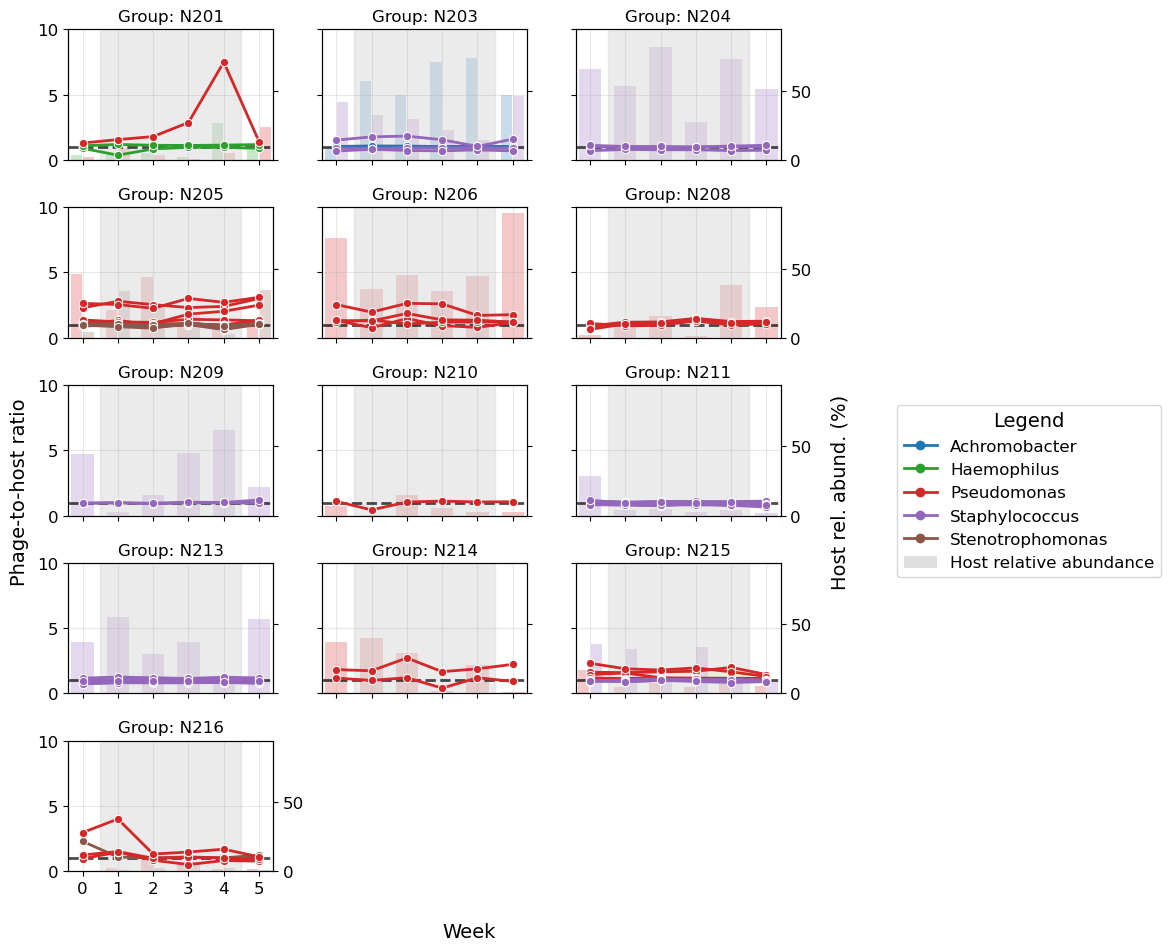

Wrote /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_6/cf_pathogen_pth_results/cf_tip_pth_trajectories.png


In [44]:
### TIP lineplot: PTH trajectories + host relative abundance bars
host_rel_genus = (
    bac_in_sample.group_by(["sample_id", "bac_genus"])
    .agg(pl.col("bac_rel").sum().alias("host_rel"))
    .rename({"bac_genus": "host_genus"})
)
exact_rel_parts = []
for pathogen, pat in _exact_host_patterns.items():
    exact_rel_parts.append(
        sylph_tax.filter(pl.col("sample_id").is_in(coverm_samples))
        .filter(pl.col("clade_name").str.contains(pat))
        .group_by("sample_id")
        .agg(pl.col("relative_abundance").sum().alias("host_rel"))
        .with_columns(pl.lit(pathogen).alias("host_genus"))
    )
host_rel = (
    host_rel_genus.join(
        pl.concat(exact_rel_parts).rename({"host_rel": "exact_rel"}),
        on=["sample_id", "host_genus"],
        how="left",
    )
    .with_columns(
        pl.when(pl.col("exact_rel").is_not_null())
        .then(pl.col("exact_rel"))
        .otherwise(pl.col("host_rel"))
        .alias("host_rel")
    )
    .select(["sample_id", "host_genus", "host_rel"])
)
# Display only viruses detected at ≥4 TIP timepoints (≈4 of 5 weeks)
tip_multi = (
    tip_pth_df.group_by(["coassembly_group", "species_cluster_id", "host_genus"])
    .agg(pl.col("timepoint").n_unique().alias("n_timepoints"))
    .filter(pl.col("n_timepoints") >= 6)
)
tip_plot_df = tip_pth_df.join(
    tip_multi.select(["coassembly_group", "species_cluster_id", "host_genus"]),
    on=["coassembly_group", "species_cluster_id", "host_genus"],
    how="inner",
)
host_rel_plot = (
    tip_plot_df.select(
        ["coassembly_group", "host_genus", "sample_id", "timepoint", "tip_status"]
    )
    .unique()
    .join(host_rel, on=["sample_id", "host_genus"], how="left")
)

print(
    f"TIP plot after ≥4 timepoints: {tip_plot_df.height} detections | "
    f"subjects: {tip_plot_df['coassembly_group'].n_unique()} | "
    f"species: {tip_plot_df['species_cluster_id'].n_unique()} "
    f"(from {tip_pth_df.height} / {tip_pth_df['species_cluster_id'].n_unique()} species)"
)

tip_pd = tip_plot_df.to_pandas().sort_values(["coassembly_group", "timepoint"])
host_pd = host_rel_plot.to_pandas()
coassembly_groups = sorted(tip_plot_df["coassembly_group"].unique().to_list())
n_groups = len(coassembly_groups)
n_cols = 3
n_rows = max((n_groups + n_cols - 1) // n_cols, 1)

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(10, 2 * n_rows), sharey=True, sharex=True
)
axes = np.atleast_1d(axes).ravel()
all_genera = sorted(tip_plot_df["host_genus"].unique().to_list())
genus_colors = {g: CF_HOST_COLORS[g] for g in all_genera if g in CF_HOST_COLORS}
host_rel_ymax = max(float(host_rel_plot["host_rel"].drop_nulls().max() or 100.0) * 1.05, 1.0)  # after ≥4-tp filter

for idx, group in enumerate(coassembly_groups):
    ax = axes[idx]
    group_data = tip_pd[tip_pd["coassembly_group"] == group]
    group_host = host_pd[host_pd["coassembly_group"] == group]
    ax.axvspan(0.5, 4.5, color="lightgrey", alpha=0.45, zorder=0)
    ax2 = ax.twinx()
    genera_here = sorted(group_host["host_genus"].dropna().unique())
    n_gen = max(len(genera_here), 1)
    bar_width = 0.7 / n_gen
    for gi, g in enumerate(genera_here):
        gdf = group_host[group_host["host_genus"] == g].sort_values("timepoint")
        dodge = (gi - (n_gen - 1) / 2.0) * bar_width
        ax2.bar(
            gdf["timepoint"].to_numpy() + dodge,
            gdf["host_rel"].fillna(0.0).to_numpy(),
            width=bar_width * 0.9,
            color=genus_colors[g],
            alpha=0.25,
            zorder=1,
            linewidth=0,
        )
    sns.lineplot(
        data=group_data,
        x="timepoint",
        y="pth",
        marker="o",
        markersize=6,
        linewidth=2,
        hue="host_genus",
        style="species_cluster_id",
        palette=genus_colors,
        dashes=False,
        ax=ax,
        legend=False,
        zorder=3,
    )
    ax.axhline(1, color="black", linestyle="--", linewidth=2, alpha=0.7, zorder=2)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax2.set_ylabel("")
    ax.set_title(f"Group: {group}", fontsize=12)
    ax.grid(alpha=0.3, zorder=0)
    ax.set_xlim(-0.4, 5.4)
    ax.set_xticks([0, 1, 2, 3, 4, 5])
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
    ax2.set_ylim(0, host_rel_ymax)
    ax2.tick_params(axis="y", labelsize=12)
    if idx % n_cols != 0:
        ax.tick_params(axis="y", labelleft=False)
    if not (idx % n_cols == n_cols - 1 or idx == n_groups - 1):
        ax2.tick_params(axis="y", labelright=False)

for idx in range(len(coassembly_groups), len(axes)):
    axes[idx].set_visible(False)

axes[0].set_ylim(0, max(10.0, float(tip_plot_df["pth"].max()) * 1.05))
legend_handles = [
    Line2D([0], [0], color=genus_colors[g], lw=2, marker="o", markersize=6, label=g)
    for g in all_genera
]
# legend_handles.append(Patch(facecolor="lightgrey", alpha=0.6, label="On TIP (weeks 1–4)"))
legend_handles.append(
    plt.Rectangle((0, 0), 1, 1, fc="grey", alpha=0.25, label="Host relative abundance")
)
fig.legend(
    handles=legend_handles,
    title="Legend",
    loc="center right",
    bbox_to_anchor=(1.2, 0.5),
    fontsize=12,
    title_fontsize=14,
    frameon=True,
)
fig.supxlabel("Week", fontsize=14, y=0.05)
fig.text(
    0.05, 0.5, "Phage-to-host ratio",
    va="center", ha="center", rotation="vertical", fontsize=14,
)
fig.text(
    0.87, 0.5, "Host rel. abund. (%)",
    va="center", ha="center", rotation="vertical", fontsize=14,
)
plt.tight_layout(rect=[0.05, 0.04, 0.86, 1])
fig.savefig(OUT_DIR / "cf_tip_pth_trajectories.png", dpi=200, bbox_inches="tight")
plt.show()
print("Wrote", OUT_DIR / "cf_tip_pth_trajectories.png")

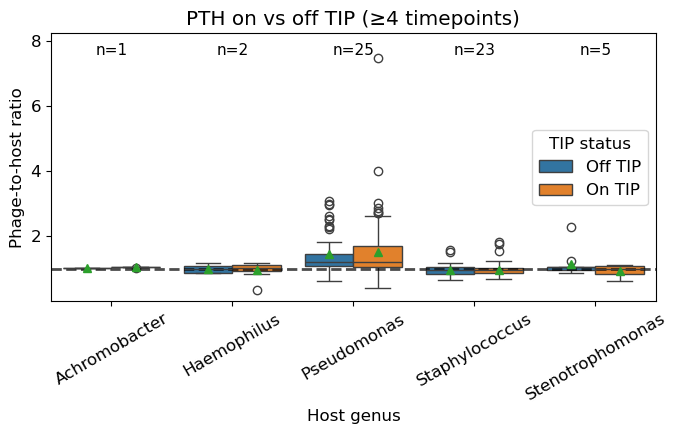

host_genus,tip_status,median_pth,n
str,str,f64,u32
"""Achromobacter""","""Off TIP""",1.023214,2
"""Achromobacter""","""On TIP""",1.05719,4
"""Haemophilus""","""Off TIP""",0.984434,4
"""Haemophilus""","""On TIP""",1.029487,8
"""Pseudomonas""","""Off TIP""",1.229367,50
"""Pseudomonas""","""On TIP""",1.225968,100
"""Staphylococcus""","""Off TIP""",0.967569,46
"""Staphylococcus""","""On TIP""",0.969762,92
"""Stenotrophomonas""","""Off TIP""",1.062054,10


Wrote /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_6/cf_pathogen_pth_results/cf_tip_pth_on_vs_off.png


In [45]:
### TIP boxplot: PTH on vs off TIP by host genus
# Uses tip_plot_df (≥4 TIP timepoints), falling back to computing it if needed.
if "tip_plot_df" not in globals():
    tip_plot_df = tip_pth_df.join(
        tip_pth_df.group_by(["coassembly_group", "species_cluster_id", "host_genus"])
        .agg(pl.col("timepoint").n_unique().alias("n_timepoints"))
        .filter(pl.col("n_timepoints") >= 4)
        .select(["coassembly_group", "species_cluster_id", "host_genus"]),
        on=["coassembly_group", "species_cluster_id", "host_genus"],
        how="inner",
    )

# n = subject × species trajectories (same unit as TIP SD plot)
order = sorted(tip_plot_df["host_genus"].unique().to_list())
counts = {
    r["host_genus"]: r["n"]
    for r in tip_plot_df.select(
        ["host_genus", "coassembly_group", "species_cluster_id"]
    )
    .unique()
    .group_by("host_genus")
    .len()
    .rename({"len": "n"})
    .iter_rows(named=True)
}
tip_status_pd = tip_plot_df.to_pandas()

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(
    data=tip_status_pd,
    x="host_genus",
    y="pth",
    order=order,
    hue="tip_status",
    hue_order=["Off TIP", "On TIP"],
    showmeans=True,
    showfliers=True,
    ax=ax,
)
y_max = float(tip_plot_df["pth"].max())
y_pad = 0.05 * y_max
for i, genus in enumerate(order):
    ax.text(i, y_max, f"n={counts[genus]}", ha="center", va="bottom", fontsize=11)
ax.axhline(1, color="black", linestyle="--", linewidth=2, alpha=0.7)
ax.set_ylabel("Phage-to-host ratio")
ax.set_xlabel("Host genus")
ax.set_title("PTH on vs off TIP (≥4 timepoints)")
ax.set_ylim(top=y_max + 2 * y_pad)
ax.tick_params(axis="x", rotation=30)
ax.legend(title="TIP status")
plt.tight_layout()
fig.savefig(OUT_DIR / "cf_tip_pth_on_vs_off.png", dpi=200, bbox_inches="tight")
plt.show()
display(
    tip_plot_df.group_by(["host_genus", "tip_status"])
    .agg([pl.col("pth").median().alias("median_pth"), pl.len().alias("n")])
    .sort(["host_genus", "tip_status"])
)
print("Wrote", OUT_DIR / "cf_tip_pth_on_vs_off.png")


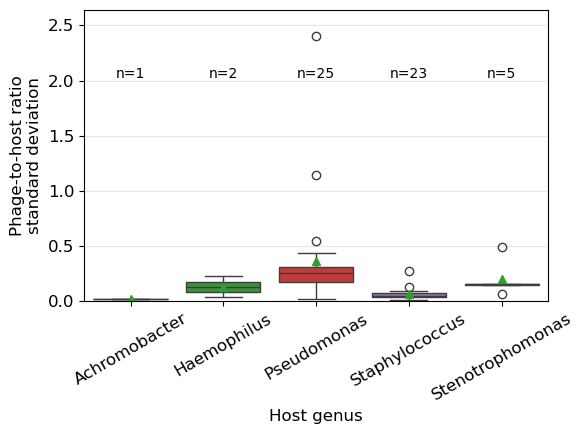

host_genus,n,median_sd
str,u32,f64
"""Pseudomonas""",25,0.260951
"""Staphylococcus""",23,0.052447
"""Stenotrophomonas""",5,0.155019
"""Haemophilus""",2,0.133741
"""Achromobacter""",1,0.021571


Overall median PTH SD: 0.11305548833064946
Wrote /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_6/cf_pathogen_pth_results/cf_tip_pth_sd_by_host.png


In [48]:
### TIP boxplot: PTH standard deviation by host genus
# Uses tip_plot_df (≥4 TIP timepoints).
if "tip_plot_df" not in globals():
    tip_plot_df = tip_pth_df.join(
        tip_pth_df.group_by(["coassembly_group", "species_cluster_id", "host_genus"])
        .agg(pl.col("timepoint").n_unique().alias("n_timepoints"))
        .filter(pl.col("n_timepoints") >= 4)
        .select(["coassembly_group", "species_cluster_id", "host_genus"]),
        on=["coassembly_group", "species_cluster_id", "host_genus"],
        how="inner",
    )

tip_pth_sd = (
    tip_plot_df.group_by(["coassembly_group", "species_cluster_id", "host_genus"])
    .agg(
        [
            pl.col("timepoint").n_unique().alias("n_weeks"),
            pl.col("pth").count().alias("n_obs"),
            pl.col("pth").mean().alias("pth_mean"),
            pl.col("pth").std().alias("pth_sd"),
        ]
    )
    .filter(pl.col("n_weeks") >= 2)
    .filter(pl.col("pth_sd").is_not_null())
)
tip_pth_sd.write_csv(
    OUT_DIR / "cf_tip_pth_sd_by_species.tsv.gz", separator="\t", compression="gzip"
)

order = sorted(tip_pth_sd["host_genus"].unique().to_list())
counts = {
    r["host_genus"]: r["len"]
    for r in tip_pth_sd.group_by("host_genus").len().iter_rows(named=True)
}
genus_colors = {g: CF_HOST_COLORS[g] for g in order if g in CF_HOST_COLORS}
sd_pd = tip_pth_sd.to_pandas()

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(
    data=sd_pd,
    x="host_genus",
    y="pth_sd",
    order=order,
    hue="host_genus",
    hue_order=order,
    palette=genus_colors,
    showmeans=True,
    legend=False,
    ax=ax,
)

y_max = float(tip_pth_sd["pth_sd"].max())
y_pad = 0.05 * y_max if y_max > 0 else 0.05
overall_median_sd = float(tip_pth_sd["pth_sd"].median())
for i, genus in enumerate(order):
    ax.text(i, 2, f"n={counts[genus]}", ha="center", va="bottom", fontsize=10)
# ax.axhline(
#     overall_median_sd,
#     color="black",
#     linestyle="--",
#     linewidth=1.5,
#     alpha=0.8,
#     label=f"median SD={overall_median_sd:.3f}",
# )
ax.set_ylabel("Phage-to-host ratio\nstandard deviation")
ax.set_xlabel("Host genus")
ax.set_ylim(bottom=0, top=y_max + 2 * y_pad)
ax.tick_params(axis="x", rotation=30)
ax.grid(alpha=0.3, axis="y")
# ax.legend(frameon=False, loc="upper right", fontsize=10)
plt.tight_layout()
fig.savefig(OUT_DIR / "cf_tip_pth_sd_by_host.png", dpi=200, bbox_inches="tight")
plt.show()
display(
    tip_pth_sd.group_by("host_genus")
    .agg([pl.len().alias("n"), pl.col("pth_sd").median().alias("median_sd")])
    .sort("n", descending=True)
)
print("Overall median PTH SD:", overall_median_sd)
print("Wrote", OUT_DIR / "cf_tip_pth_sd_by_host.png")